In [1]:
import itertools

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.ticker as tck
from collections import defaultdict

In [2]:
with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [3]:
def ed(d):
    if d % 4 == 1:
        return 1
    elif d % 4 == 3:
        return 1j
def ls(n, d):
    return int(legendre_symbol(n, d))
def gnd(n, d):
    if n % 2 == 0 and (n + d + 1)/2 % 2 == 0:
        return n*(n*n - d*(d + 6) + 3)
    elif n % 2 == 0 and (n + d + 1)/2 % 2 == 1:
        return n*(n*n - d*(d - 6) + 3)
    elif n % 4 == 1:
        return n * (n*n + 3) + 2*d*d * (-5*n + 3)
    elif n % 4 == 3:
        return n * (n*n + 3) + 2*d*d * (n + 3)
def omega(d):
    return np.exp( 2j * np.pi / d)
def lam(n, d):
    a = ed(d) * ls(n, d)
    lam_temp = pow(omega(d), -gnd(n, d) / 48) / a
    return lam_temp.conj()

In [4]:
def A_t(t, n):
    a1 = lam(n, 3)/np.sqrt(3)
    M = np.zeros((4,4), dtype=complex)
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    for k in range(3):
        b1 = omega(3)**(n * t * k) * omega(3)**(n * k * (k + 1))
        c1 = np.linalg.matrix_power(X @ np.linalg.matrix_power(Z, k), n)  # (XZ^k)^n
        M += b1 * c1

    return a1 * M

def B_k(k, n):
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    mtx = np.linalg.matrix_power(Z @ np.linalg.matrix_power(X, k), n % 3)
    return mtx

def C_k(k, n):
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    if k == 0:
        return np.linalg.matrix_power(Z, n % 3)
    elif k == 1:
        return np.linalg.matrix_power(Z @ X, n % 3)

In [5]:
def Ry01(theta):
    mtx = np.array([
        [np.cos(theta/2), -np.sin(theta/2), 0, 0],
        [np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

def Ry02(theta):
    mtx = np.array([
        [np.cos(theta/2),   0, -np.sin(theta/2),    0],
        [0,                 1, 0,                   0],
        [np.sin(theta/2),   0, np.cos(theta/2),     0],
        [0,                 0, 0,                   1]
    ])
    return Operator(mtx)

def Ry12(theta):
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -np.sin(theta/2), 0],
        [0, np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

In [175]:
def I_g_cor(qc):
    suma = 0
    om = omega(3)

    A = [Operator(A_t(0, 1)), Operator(A_t(1, 1)), Operator(A_t(2, 1))]
    B = [Operator(B_k(0, 1)), Operator(B_k(1, 1)), Operator(B_k(2, 1))]
    C = [Operator(C_k(0, 1)), Operator(C_k(1, 1))]
    a1 = 1/(lam(1, 3) * np.sqrt(3))
    a2 = om/(2 * lam(1, 3) * np.sqrt(3))

    ev_list = [Statevector(qc).expectation_value(B[0] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[0] ^ C[1]), Statevector(qc).expectation_value(B[0] ^ A[1] ^ C[1]), Statevector(qc).expectation_value(B[0] ^ A[2] ^ C[1])]

    op1 = ev_list[0] + ev_list[1] + ev_list[2]
    op2 = ev_list[3] + om**(2) * ev_list[4] + om**(1) * ev_list[5]
    op3 = ev_list[6] + om**(1) * ev_list[7] + om**(2) * ev_list[8]
    op4 = ev_list[9] + om**(2) * ev_list[10] + om**(1) * ev_list[11]

    suma += a1 * (op1 + op3)
    suma += a2 * (op2 + op4)

    print("Print ev ops:")
    print(a1 * op1)
    print(a2 * op2)
    print(a1 * op3)
    print(a2 * op4)

    print("Print evs:")
    for i in ev_list:
        print(i)

    A = [Operator(A_t(0, 2)), Operator(A_t(1, 2)), Operator(A_t(2, 2))]
    B = [Operator(B_k(0, 2)), Operator(B_k(1, 2)), Operator(B_k(2, 2))]
    C = [Operator(C_k(0, 2)), Operator(C_k(1, 2))]
    a1 = 1/(lam(2, 3) * np.sqrt(3))
    a2 = om**2 / (2 * lam(2, 3) * np.sqrt(3))

    ev_list = [Statevector(qc).expectation_value(B[0] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[1] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[0] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[1] ^ C[0]), Statevector(qc).expectation_value(B[2] ^ A[2] ^ C[0]), Statevector(qc).expectation_value(B[0] ^ A[0] ^ C[1]), Statevector(qc).expectation_value(B[0] ^ A[1] ^ C[1]), Statevector(qc).expectation_value(B[0] ^ A[2] ^ C[1])]

    op1 = ev_list[0] + ev_list[1] + ev_list[2]
    op2 = ev_list[3] + om**(1) * ev_list[4] + om**(2) * ev_list[5]
    op3 = ev_list[6] + om**(2) * ev_list[7] + om**(1) * ev_list[8]
    op4 = ev_list[9] + om**(1) * ev_list[10] + om**(2) * ev_list[11]

    suma += a1 * (op1 + op3)
    suma += a2 * (op2 + op4)


    print("-----------------------")
    print("Print ev ops:")
    print(a1 * op1)
    print(a2 * op2)
    print(a1 * op3)
    print(a2 * op4)

    print("Print evs:")
    for i in ev_list:
        print(i)

    return suma

In [7]:
def A_clas(n, alfa):
    return omega(3)**(n*alfa)

def B_clas(n, beta):
    return omega(3)**(n*beta)
def C_clas(n, gamma):
    return omega(3)**(n*gamma)

def I_g_classic(alfa0, alfa1, alfa2, beta0, beta1, beta2, gamma0, gamma1):
    suma = 0
    om = omega(3)

    A0 = A_clas(1, alfa0)
    A1 = A_clas(1, alfa1)
    A2 = A_clas(1, alfa2)
    B0 = B_clas(1, beta0)
    B1 = B_clas(1, beta1)
    B2 = B_clas(1, beta2)
    C0 = C_clas(1, gamma0)
    C1 = C_clas(1, gamma1)

    a1 = 1/(lam(1, 3) * np.sqrt(3))
    a2 = om**(1) / (2 * lam(1, 3) * np.sqrt(3))

    op1 = a1 * ((A0 + A1 + A2) * B0 * C0)
    op2 = a2 * (A0 * B1 * C0 + omega(3)**(2) * A1 * B1 * C0 + omega(3)**(1) * A2 * B1 * C0)
    op3 = a1 * (A0 * B2 * C0 + omega(3)**(1) * A1 * B2 * C0 + omega(3)**(2) * A2 * B2 * C0)
    op4 = a2 * (A0 * B0 * C1 + omega(3)**(2) * A1 * B0 * C1 + omega(3)**(1) * A2 * B0 * C1)

    A0 = A_clas(2, alfa0)
    A1 = A_clas(2, alfa1)
    A2 = A_clas(2, alfa2)
    B0 = B_clas(2, beta0)
    B1 = B_clas(2, beta1)
    B2 = B_clas(2, beta2)
    C0 = C_clas(2, gamma0)
    C1 = C_clas(2, gamma1)

    a12 = 1/(lam(2, 3) * np.sqrt(3))
    a22 = om**(2) / (2 * lam(2, 3) * np.sqrt(3))

    op12 = a12 * ((A0 + A1 + A2) * B0 * C0)
    op22 = a22 * (A0 * B1 * C0 + omega(3)**(1) * A1 * B1 * C0 + omega(3)**(2) * A2 * B1 * C0)
    op32 = a12 * (A0 * B2 * C0 + omega(3)**(2) * A1 * B2 * C0 + omega(3)**(1) * A2 * B2 * C0)
    op42 = a22 * (A0 * B0 * C1 + omega(3)**(1) * A1 * B0 * C1 + omega(3)**(2) * A2 * B0 * C1)

    oplist = [op1, op2, op3, op4, op12, op22, op32, op42]

    suma += sum(oplist)

    return suma

In [8]:
I_clas_max = I_g_classic(0, 0, 0, 0, 0, 0, 0, 0)
i_max = (0, 0, 0, 0, 0, 0, 0, 0)
for i in product(range(3), repeat=8):
    Itemp = I_g_classic(i[0], i[1], i[2], i[3], i[4], i[5], i[6], i[7])
    if Itemp > I_clas_max:
        I_clas_max = Itemp
        i_max = i

In [9]:
I_clas_max

np.complex128(5.63815572471545-2.275957200481571e-15j)

In [63]:
6*np.cos(np.pi/9)

np.float64(5.638155724715451)

In [10]:
ghz, g3 = create_ame_circuit(3, 3, graph_type='line')

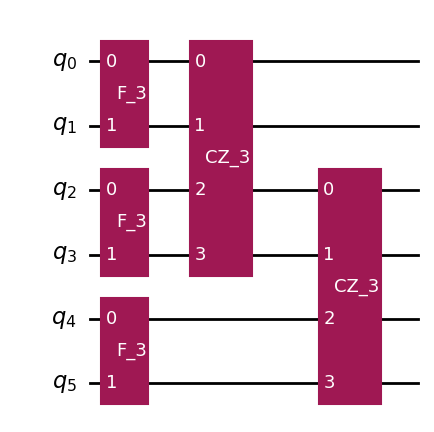

In [8]:
ghz.draw('mpl')

In [24]:
I_g_cor(ghz)

Print ev ops:
(1.0000000000000004-1.942890293094024e-16j)
(0.5000000000000001-7.216449660063518e-16j)
(1.0000000000000002-2.4424906541753444e-15j)
(0.5000000000000001-7.216449660063518e-16j)
Print evs:
(0.5685790213016293+0.10025582212029027j)
(0.5685790213016287+0.10025582212029055j)
(0.568579021301629+0.10025582212029008j)
(-0.19746542181734966-0.542531787566249j)
(0.5685790213016293+0.10025582212028966j)
(-0.3711135994842796+0.44227596544595915j)
(0.5685790213016291+0.10025582212028969j)
(-0.19746542181735063-0.5425317875662488j)
(-0.3711135994842787+0.44227596544596004j)
(-0.19746542181734966-0.5425317875662491j)
(0.5685790213016292+0.1002558221202897j)
(-0.37111359948427947+0.44227596544595915j)
-----------------------
Print ev ops:
(1-3.885780586188048e-16j)
(0.5000000000000001-1.3322676295501878e-15j)
(1.0000000000000007-4.551914400963142e-15j)
(0.5000000000000001-1.3322676295501878e-15j)
Print evs:
(0.568579021301629-0.1002558221202906j)
(0.5685790213016289-0.10025582212029094j

np.complex128(6.000000000000002-1.1657341758564144e-14j)

In [8]:
def rng_qc_3():
    amps = np.zeros(4, dtype=complex)
    sel = [i for i in range(3)]
    amps[sel] = 1/np.sqrt(3)

    rngqc = QuantumCircuit(2)
    rngqc.append(StatePreparation(amps), [0, 1])
    rngqc.measure_all()
    return rngqc

def get_random_index_quant(sam, qcrng):

    while True:
        job = sam.run([qcrng])
        result = job.result()[0].data.meas.get_bitstrings()
        res = int(result[0], 2)
        if res not in range(3):
            continue
        else:
            break

    return res

def get_random_index(finish):
    rng = np.random.default_rng()
    res = rng.integers(finish)
    return res

def get_ind(n, m, l):
    order = [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]

    while True:
        if (n, m, l) in order:
            break
        else:
            n = get_random_index(3)
            m = get_random_index(3)
            l = get_random_index(2)

    pos = {t:i for i,t in enumerate(order)}
    return pos[(n, m, l)], n, m, l

def ABC_list(n, m, l, im, op):
    ind, n, m, l = get_ind(n, m, l)
    if im:
        Aret = op[1][ind]
    else:
        Aret = op[0][ind]
    return Aret, n, m, l


def calculate_I_g(ev_list_re, ev_list_im):

    om = omega(3)

    for im in [False, True]:
        if im:
            ev_list = ev_list_im
        else:
            ev_list = ev_list_re

        a1 = 1/(lam(1, 3) * np.sqrt(3))
        a2 = om/(2 * lam(1, 3) * np.sqrt(3))

        op1 = a1 * (ev_list[0] + ev_list[1] + ev_list[2])
        op2 = a2 * (ev_list[3] + omega(3)**(2) * ev_list[4] + omega(3)**(1) * ev_list[5])
        op3 = a1 * (ev_list[6] + omega(3)**(1) * ev_list[7] + omega(3)**(2) * ev_list[8])
        op4 = a2 * (ev_list[9] + omega(3)**(2) * ev_list[10] + omega(3)**(1) * ev_list[11])

        # Wyrazy dla n=2
        a12 = 1/(lam(2, 3) * np.sqrt(3))
        a22 = om**2/(2 * lam(2, 3) * np.sqrt(3))

        op1cc = a12 * (ev_list[12] + ev_list[13] + ev_list[14])
        op2cc = a22 * (ev_list[15] + omega(3)**(1) * ev_list[16] + omega(3)**(2) * ev_list[17])
        op3cc = a12 * (ev_list[18] + omega(3)**(2) * ev_list[19] + omega(3)**(1) * ev_list[20])
        op4cc = a22 * (ev_list[21] + omega(3)**(1) * ev_list[22] + omega(3)**(2) * ev_list[23])

        op_list = [op1, op2, op3, op4, op1cc, op2cc, op3cc, op4cc]
        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return suma_re + suma_im*1j

In [9]:

def I_g_random(qc, est, shots, op, op2):

    ev_dict_re = {}
    ev_dict_im = {}

    ini_time_for_now = datetime.now()

    for i in range(shots):
        n = get_random_index(3)
        m = get_random_index(3)
        l = get_random_index(2)

        ncc = get_random_index(3)
        mcc = get_random_index(3)
        lcc = get_random_index(2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, n, m, l = ABC_list(n, m, l, False, op)
        ABcc, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, False, op2)
        AB_im, n, m, l = ABC_list(n, m, lcc, True, op)
        ABcc_im, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, True, op2)

        est.options.default_shots = 100
        #est.options.environment.job_tags = ["Estimator", f'Shot {i} of {shots}']
        job = est.run([(qc, AB), (qc, ABcc), (qc, AB_im), (qc, ABcc_im)])

        # dla RE
        ev = job.result()[0].data.evs
        key_re = (0, n, m)

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = job.result()[1].data.evs
        key_cc = (1, ncc, mcc)
        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = job.result()[2].data.evs
        key_re_im = (0, n, m)

        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = job.result()[3].data.evs
        key_cc_im = (1, ncc, mcc)

        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

        # if i == 0:
        #     time_for_one = datetime.now() - ini_time_for_now
        #     time_for_all = time_for_one * shots
        #     print(f'Estimated time for all shots: {time_for_all}')
        #     print(f'Estimated finish time: {ini_time_for_now + time_for_all}')

        # print(f'Shot {i+1} of {shots}')

    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    final_ev_list_re = []

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((1, n, m)))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((1, n, m)))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [10]:
# to jest dobrze
def create_isa_ops(base_qc):
    A_list = [A_t(0, 1), A_t(1, 1), A_t(2, 1)]
    B_list = [B_k(0, 1), B_k(1, 1), B_k(2, 1)]
    A2_list = [A_t(0, 2), A_t(1, 2), A_t(2, 2)]
    B2_list = [B_k(0, 2), B_k(1, 2), B_k(2, 2)]
    C_list = [C_k(0, 1), C_k(1, 1)]
    C2_list = [C_k(0, 2), C_k(1, 2)]

    op_list = []
    op2_list = []

    op_list_im = []
    op2_list_im = []
    for im in [False, True]:
        for ord in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]:
            n = ord[0]
            m = ord[1]
            l = ord[2]

            A = A_list[n]
            B = B_list[m]
            C = C_list[l]

            A2 = A2_list[n]
            B2 = B2_list[m]
            C2 = C2_list[l]

            AB = Operator(B) ^ Operator(A) ^ Operator(C)
            AB2 = Operator(B2) ^ Operator(A2) ^ Operator(C2)
            if im:
                A_op = -0.5j * (AB - AB.adjoint())
                A2_op = -0.5j * (AB2 - AB2.adjoint())
            else:
                A_op = 0.5 * (AB + AB.adjoint())
                A2_op = 0.5 * (AB2 + AB2.adjoint())

            op = SparsePauliOp.from_operator(A_op)
            op2 = SparsePauliOp.from_operator(A2_op)

            op_isa = op.apply_layout(layout=base_qc.layout)
            op2_isa = op2.apply_layout(layout=base_qc.layout)

            if im:
                op_list_im.append(op_isa)
                op2_list_im.append(op2_isa)
            else:
                op_list.append(op_isa)
                op2_list.append(op2_isa)

    return [op_list, op_list_im], [op2_list, op2_list_im]

In [11]:
def calc_I_g_ry(est, resolution, qtr2):
    theta_list = np.linspace(0, 2*np.pi, resolution)

    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    ry02_list = [Ry02(theta) for theta in theta_list]
    ry02_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry02_list]

    ry12_list = [Ry12(theta) for theta in theta_list]
    ry12_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry12_list]

    qc01_list = []
    for ry in ry01_qc_list:
        qctemp = qtr2.copy()
        qctemp.append(ry, [0, 1])
        qc01_list.append(qctemp)

    qc02_list = []
    for ry in ry02_qc_list:
        qctemp = qtr2.copy()
        qctemp.append(ry, [0, 1])
        qc02_list.append(qctemp)

    qc12_list = []
    for ry in ry12_qc_list:
        qctemp = qtr2.copy()
        qctemp.append(ry, [0, 1])
        qc12_list.append(qctemp)

    oplist, oplist2 = create_isa_ops(qtr2)

    ops = oplist[0]
    ops_im = oplist[1]
    ops2 = oplist2[0]
    ops2_im = oplist2[1]

    pubs01 = [(qc.decompose().decompose().decompose(), [ops + ops2, ops_im + ops2_im]) for qc in qc01_list]
    pubs02 = [(qc.decompose().decompose().decompose(), [ops + ops2, ops_im + ops2_im]) for qc in qc02_list]
    pubs12 = [(qc.decompose().decompose().decompose(), [ops + ops2, ops_im + ops2_im]) for qc in qc12_list]
    print(len(pubs01))
    print("Jobs 1")
    job01 = est.run(pubs01)
    results01 = job01.result()

    ig_list01 = [np.real(calculate_I_g(results01[i].data.evs[0], results01[i].data.evs[1])) for i in range(resolution)]
    print("Jobs 2")
    job02 = est.run(pubs02)
    results02 = job02.result()

    ig_list02 = [np.real(calculate_I_g(results02[i].data.evs[0], results02[i].data.evs[1])) for i in range(resolution)]
    print("Jobs 3")
    job12 = est.run(pubs12)
    results12 = job12.result()

    ig_list12 = [np.real(calculate_I_g(results12[i].data.evs[0], results12[i].data.evs[1])) for i in range(resolution)]

    fig, ax = plt.subplots(3, 1, figsize=(10, 10))

    ax[0].plot(theta_list / np.pi, ig_list01, "o-", label="Ry01", color="red")
    ax[1].plot(theta_list / np.pi, ig_list02, "o-", label="Ry02", color="green")
    ax[2].plot(theta_list / np.pi, ig_list12, "o-", label="Ry12", color="blue")

    for i in range(3):
        ax[i].axhline(y=6*np.cos(np.pi/9), linestyle="--")
        ax[i].xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))

    fig.supxlabel("Theta")
    fig.supylabel("CHSH witness")
    fig.legend(loc="upper center", ncol=3)
    plt.show()

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import itertools

In [13]:
# igstat dobrze dziala
def I_g_stat(qc, est, shots, op, op2):
    pubs = []

    n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = [], [], [], [], [], []

    for i in range(shots):
        n = get_random_index(3)
        m = get_random_index(3)
        l = get_random_index(2)

        ncc = get_random_index(3)
        mcc = get_random_index(3)
        lcc = get_random_index(2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, n, m, l = ABC_list(n, m, l, False, op)
        ABcc, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, False, op2)
        AB_im, n, m, l = ABC_list(n, m, l, True, op)
        ABcc_im, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, True, op2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(n)
        m_list.append(m)
        l_list.append(l)

        ncc_list.append(ncc)
        mcc_list.append(mcc)
        lcc_list.append(lcc)

    job = est.run(pubs)
    results = job.result()
    # for res, n, m, l, ncc, mcc, lcc in zip(results, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list):
    #     print(res.data.evs, n, m, l, ncc, mcc, lcc)
    return results, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list

In [14]:
def I_g_from_results(qc, est, shots, op, op2):

    results, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = I_g_stat(qc, est, shots, op, op2)

    ev_dict_re = {}
    ev_dict_im = {}

    for res, n, m, l, ncc, mcc, lcc in zip(range(len(results)), n_list, m_list, l_list, ncc_list, mcc_list, lcc_list):
        ev = results[res].data.evs[0]
        key_re = (0, n, m, l)

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = results[res].data.evs[1]
        key_cc = (1, ncc, mcc, lcc)
        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = results[res].data.evs[2]
        key_re_im = (0, n, m, l)

        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = results[res].data.evs[3]
        key_cc_im = (1, ncc, mcc, lcc)

        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    print(len(mean_ev_list.keys()))

    final_ev_list_re = []

    for ord in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]:
            final_ev_list_re.append(mean_ev_list.get((0, ord[0], ord[1], ord[2])))

    for ord in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]:
            final_ev_list_re.append(mean_ev_list.get((1, ord[0], ord[1], ord[2])))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for ord in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]:
        final_ev_list_im.append(mean_ev_list_im.get((0, ord[0], ord[1], ord[2])))

    for ord in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]:
        final_ev_list_im.append(mean_ev_list_im.get((1, ord[0], ord[1], ord[2])))

    print("Len re", len(final_ev_list_re))
    print("Len im", len(final_ev_list_im))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [ ]:
def I_g_from_results(qc, est, shots, op, op2):
    results, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = I_g_stat(qc, est, shots, op, op2)

    from collections import defaultdict
    ev_re = defaultdict(list)  # keys: (chan, n, m, l)
    ev_im = defaultdict(list)
    std_re = defaultdict(list)
    std_im = defaultdict(list)


    for idx, res in enumerate(results):
        evs = res.data.evs
        stds = res.data.stds
        ev_re[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(evs[0])
        ev_re[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(evs[1])
        std_re[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(stds[0]**2)
        std_re[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(stds[1]**2)

        ev_im[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(evs[2])
        ev_im[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(evs[3])
        std_im[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(stds[2]**2)
        std_im[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(stds[3]**2)



    import numpy as np
    mean_re = {k: float(np.mean(v)) for k, v in ev_re.items()}
    mean_im = {k: float(np.mean(v)) for k, v in ev_im.items()}
    mean_re_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_re.items()}
    mean_im_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_im.items()}

    order_base = [
        (0,0,0), (1,0,0), (2,0,0),
        (0,1,0), (1,1,0), (2,1,0),
        (0,2,0), (1,2,0), (2,2,0),
        (0,0,1), (1,0,1), (2,0,1),
    ]


    order_cc = order_base  


    def gather(means_dict, chan, order):
        vals, missing = [], []
        for (n,m,l) in order:
            key = (chan, n, m, l)
            if key not in means_dict:
                missing.append(key)
                vals.append(None)
            else:
                vals.append(means_dict[key])
        return vals, missing

    re_main, miss_re0 = gather(mean_re, 0, order_base)
    re_cc,   miss_re1 = gather(mean_re, 1, order_cc)
    im_main, miss_im0 = gather(mean_im, 0, order_base)
    im_cc,   miss_im1 = gather(mean_im, 1, order_cc)

    re_main_std, miss_re0_std = gather(mean_re_std, 0, order_base)
    re_cc_std,   miss_re1_std = gather(mean_re_std, 1, order_cc)
    im_main_std, miss_im0_std = gather(mean_im_std, 0, order_base)
    im_cc_std,   miss_im1_std = gather(mean_im_std, 1, order_cc)

    final_ev_list_re = re_main + re_cc
    final_ev_list_im = im_main + im_cc

    final_std_list_re = re_main_std + re_cc_std
    final_std_list_im = im_main_std + im_cc_std

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    std_val = calculate_I_g_std(final_std_list_re, final_std_list_im)

    return ig_val, std_val

In [61]:
def calculate_I_g_std(std_list_re, std_list_im):

    om = omega(3)

    for im in [False, True]:
        if im:
            std_list = std_list_im
        else:
            std_list = std_list_re


        a1_n1 = 1/(lam(1, 3) * np.sqrt(3))
        a2_n1 = om/(2 * lam(1, 3) * np.sqrt(3))

        # Obliczanie wariancji dla każdego składnika
        var1 = (abs(a1_n1)**2) * (std_list[0]**2 + std_list[1]**2 + std_list[2]**2)
        var2 = (abs(a2_n1)**2) * (std_list[3]**2 +
                                  abs(omega(3)**(2))**2 * std_list[4]**2 +
                                  abs(omega(3)**(1))**2 * std_list[5]**2)
        var3 = (abs(a1_n1)**2) * (std_list[6]**2 +
                                  abs(omega(3)**(1))**2 * std_list[7]**2 +
                                  abs(omega(3)**(2))**2 * std_list[8]**2)
        var4 = (abs(a2_n1)**2) * (std_list[9]**2 +
                                  abs(omega(3)**(2))**2 * std_list[10]**2 +
                                  abs(omega(3)**(1))**2 * std_list[11]**2)


        a1_n2 = 1/(lam(1, 3) * np.sqrt(3))
        a2_n2 = om**2/(2 * lam(2, 3) * np.sqrt(3))

        var1cc = (abs(a1_n2)**2) * (std_list[12]**2 + std_list[13]**2 + std_list[14]**2)
        var2cc = (abs(a2_n2)**2) * (std_list[15]**2 + omega(3)**(1)**2 * std_list[16]**2 + omega(3)**(2)**2 * std_list[17]**2)
        var3cc = (abs(a1_n2)**2) * (std_list[18]**2 + omega(3)**(2)**2 * std_list[19]**2 + omega(3)**(1)**2 * std_list[20]**2)
        var4cc = (abs(a2_n2)**2) * (std_list[21]**2 + omega(3)**(1)**2 * std_list[22]**2 + omega(3)**(2)**2 * std_list[23]**2)

        op_list = [var1, var2, var3, var4, var1cc, var2cc, var3cc, var4cc]

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return np.sqrt(suma_re) + np.sqrt(suma_im)*1j

In [49]:
import math

In [ ]:
from itertools import chain

def split_equal(seq, parts, length):
    size = length // parts
    return [seq[i:i+size] for i in range(0, length, size)]

def prepare_pubs(qc, shots, op, op2, div_jobs):
    pubs = []

    n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = [], [], [], [], [], []

    for i in range(shots):
        n = get_random_index(3)
        m = get_random_index(3)
        l = get_random_index(2)

        ncc = get_random_index(3)
        mcc = get_random_index(3)
        lcc = get_random_index(2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, n, m, l = ABC_list(n, m, l, False, op)
        ABcc, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, False, op2)
        AB_im, n, m, l = ABC_list(n, m, l, True, op)
        ABcc_im, ncc, mcc, lcc = ABC_list(ncc, mcc, lcc, True, op2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(n)
        m_list.append(m)
        l_list.append(l)

        ncc_list.append(ncc)
        mcc_list.append(mcc)
        lcc_list.append(lcc)

    pub_cuts = split_equal(pubs, div_jobs, shots)

    return pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list

def I_g_stat(est, pub_cuts, shot, shots):  # shot, shots
    parts = []

    for p, num in zip(pub_cuts, range(len(pub_cuts))):
        print(f'{shot + 1} of {shots}, Jobs num: {num + 1}')
        parts.append(est.run(p))

    return parts

def I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list, l_list, lcc_list):

    results = list(chain.from_iterable([p.result() for p in parts]))

    from collections import defaultdict
    ev_re = defaultdict(list)  # keys: (chan, n, m, l)
    ev_im = defaultdict(list)
    std_re = defaultdict(list)
    std_im = defaultdict(list)


    for idx, res in enumerate(results):
        evs = res.data.evs
        stds = res.data.stds
        ev_re[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(evs[0])
        ev_re[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(evs[1])
        std_re[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(stds[0]**2)
        std_re[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(stds[1]**2)

        ev_im[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(evs[2])
        ev_im[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(evs[3])
        std_im[(0, n_list[idx],   m_list[idx],   l_list[idx])].append(stds[2]**2)
        std_im[(1, ncc_list[idx], mcc_list[idx], lcc_list[idx])].append(stds[3]**2)



    import numpy as np
    mean_re = {k: float(np.mean(v)) for k, v in ev_re.items()}
    mean_im = {k: float(np.mean(v)) for k, v in ev_im.items()}
    mean_re_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_re.items()}
    mean_im_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_im.items()}

    order_base = [
        (0,0,0), (1,0,0), (2,0,0),
        (0,1,0), (1,1,0), (2,1,0),
        (0,2,0), (1,2,0), (2,2,0),
        (0,0,1), (1,0,1), (2,0,1),
    ]


    order_cc = order_base  

    def gather(means_dict, chan, order):
        vals, missing = [], []
        for (n,m,l) in order:
            key = (chan, n, m, l)
            if key not in means_dict:
                missing.append(key)
                vals.append(None)
            else:
                vals.append(means_dict[key])
        return vals, missing

    re_main, miss_re0 = gather(mean_re, 0, order_base)
    re_cc,   miss_re1 = gather(mean_re, 1, order_cc)
    im_main, miss_im0 = gather(mean_im, 0, order_base)
    im_cc,   miss_im1 = gather(mean_im, 1, order_cc)

    re_main_std, miss_re0_std = gather(mean_re_std, 0, order_base)
    re_cc_std,   miss_re1_std = gather(mean_re_std, 1, order_cc)
    im_main_std, miss_im0_std = gather(mean_im_std, 0, order_base)
    im_cc_std,   miss_im1_std = gather(mean_im_std, 1, order_cc)

    final_ev_list_re = re_main + re_cc
    final_ev_list_im = im_main + im_cc

    final_std_list_re = re_main_std + re_cc_std
    final_std_list_im = im_main_std + im_cc_std

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    std_val = calculate_I_g_std(final_std_list_re, final_std_list_im)

    return ig_val, std_val

In [ ]:
def split_equal(seq, parts):
    n = len(seq)
    if parts <= 0:
        raise ValueError("parts must be >= 1")
    base, rem = divmod(n, parts)
    if base == 0:

        return [seq[i:i+1] for i in range(n)]
    out = []
    start = 0
    for i in range(parts):
        size = base + (1 if i < rem else 0)
        if size == 0:
            break
        out.append(seq[start:start+size])
        start += size
    return out
def prepare_pubs(qc, shots, op, op2, div_jobs):
    pubs = []
    n_list, m_list, l_list = [], [], []
    ncc_list, mcc_list, lcc_list = [], [], []

    for _ in range(shots):

        n0, m0, l0   = get_random_index(3), get_random_index(3), get_random_index(2)
        n0c, m0c, l0c = get_random_index(3), get_random_index(3), get_random_index(2)


        AB,     nA, mA, lA = ABC_list(n0,  m0,  l0,  False, op)
        ABcc,   nC, mC, lC = ABC_list(n0c, m0c, l0c, False, op2)


        AB_im,   _, _, _ = ABC_list(nA, mA, lA, True, op)
        ABcc_im, _, _, _ = ABC_list(nC, mC, lC, True, op2)

        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(nA);   m_list.append(mA);   l_list.append(lA)
        ncc_list.append(nC); mcc_list.append(mC); lcc_list.append(lC)

    pub_cuts = split_equal(pubs, div_jobs)
    return pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list

In [21]:
from collections import defaultdict

In [ ]:
def split_equal(seq, parts):
    n = len(seq)
    if parts <= 0:
        raise ValueError("parts must be >= 1")
    base, rem = divmod(n, parts)
    if base == 0:
        return [seq[i:i+1] for i in range(n)]
    out = []
    start = 0
    for i in range(parts):
        size = base + (1 if i < rem else 0)
        if size == 0:
            break
        out.append(seq[start:start+size])
        start += size
    return out

def prepare_pubs(
    qc, shots, op, op2, div_jobs,
    order_base=None,
    require_cc_coverage=False,
    order_base_cc=None,
    max_extra_iters=100_000
):

    target_main = set(tuple(map(int, t)) for t in (order_base or []))
    need_main_coverage = len(target_main) > 0

    if require_cc_coverage:
        if order_base_cc is None:
            
            target_cc = set(target_main)
        else:
            target_cc = set(tuple(map(int, t)) for t in order_base_cc)
        need_cc_coverage = len(target_cc) > 0
    else:
        target_cc = set()
        need_cc_coverage = False

    seen_main, seen_cc = set(), set()

   
    counts_main = defaultdict(int)
    counts_cc = defaultdict(int)

    pubs = []
    n_list, m_list, l_list = [], [], []
    ncc_list, mcc_list, lcc_list = [], [], []


    def coverage_ok():
        ok_main = (not need_main_coverage) or target_main.issubset(seen_main)
        ok_cc   = (not need_cc_coverage)   or target_cc.issubset(seen_cc)
        return ok_main and ok_cc

    iters = 0

    while (len(pubs) < shots) or (not coverage_ok()):
        iters += 1
        if iters > shots + max_extra_iters:
            missing_main = sorted(target_main - seen_main) if need_main_coverage else []
            missing_cc = sorted(target_cc - seen_cc) if need_cc_coverage else []
            raise RuntimeError(
                "Nie udało się pokryć wszystkich trójek z order_base w rozsądnym limicie.\n"
                f"Brakujące main: {missing_main}\n"
                f"Brakujące cc:   {missing_cc}"
            )


        n0, m0, l0    = get_random_index(3), get_random_index(3), get_random_index(2)
        n0c, m0c, l0c = get_random_index(3), get_random_index(3), get_random_index(2)


        AB,   nA, mA, lA   = ABC_list(n0,  m0,  l0,  False, op)
        ABcc, nC, mC, lC   = ABC_list(n0c, m0c, l0c, False, op2)

        AB_im,   _, _, _   = ABC_list(nA, mA, lA, True, op)
        ABcc_im, _, _, _   = ABC_list(nC, mC, lC, True, op2)

        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(nA);   m_list.append(mA);   l_list.append(lA)
        ncc_list.append(nC); mcc_list.append(mC); lcc_list.append(lC)


        t_main = (int(nA), int(mA), int(lA))
        counts_main[t_main] += 1
        if need_main_coverage and (t_main in target_main):
            seen_main.add(t_main)

        if need_cc_coverage:
            t_cc = (int(nC), int(mC), int(lC))
            counts_cc[t_cc] += 1
            if t_cc in target_cc:
                seen_cc.add(t_cc)

    pub_cuts = split_equal(pubs, div_jobs)
    return pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list

In [23]:
from itertools import chain
import numpy as np
from collections import defaultdict

In [226]:
np.random.normal(0, 1)

2.3170052510724752

In [194]:
np.random.normal(1)

1.4399432476863017

In [ ]:
def I_g_from_results_with_std(parts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list):
    results_nested = [p.result() for p in parts]
    results = list(chain.from_iterable(results_nested))


    N = len(results)
    assert N == len(n_list) == len(m_list) == len(l_list) == len(ncc_list) == len(mcc_list) == len(lcc_list), \
        f"Niezgodne długości: results={N}, n={len(n_list)}, m={len(m_list)}, l={len(l_list)}, " \
        f"ncc={len(ncc_list)}, mcc={len(mcc_list)}, lcc={len(lcc_list)}"

    ev_re, ev_im = defaultdict(list), defaultdict(list)
    var_re, var_im = defaultdict(list), defaultdict(list)  

    for idx, res in enumerate(results):
        evs  = res.data.evs  
        stds = res.data.stds  

        # if np.abs(np.random.normal(0, 1)) > 1:
        #     evs[0] = np.float64(np.nan)

        if (np.isnan(evs[0]) is np.True_) or (np.isnan(evs[1]) is np.True_) or (np.isnan(evs[2]) is np.True_) or np.isnan(evs[3]) is np.True_:
            print(f"EVS NaN")
            print(evs)
            continue
        else:
            print("EVS OK")
            vars_ = [s*s for s in stds]

            k0 = (0, n_list[idx],   m_list[idx],   l_list[idx])
            k1 = (1, ncc_list[idx], mcc_list[idx], lcc_list[idx])

            ev_re[k0].append(evs[0]); var_re[k0].append(vars_[0])
            ev_re[k1].append(evs[1]); var_re[k1].append(vars_[1])
            ev_im[k0].append(evs[2]); var_im[k0].append(vars_[2])
            ev_im[k1].append(evs[3]); var_im[k1].append(vars_[3])

    mean_re = {k: float(np.mean(v)) for k, v in ev_re.items()}
    mean_im = {k: float(np.mean(v)) for k, v in ev_im.items()}


    def sem_from_vars(vars_dict):
        out = {}
        for k, vs in vars_dict.items():
            N = len(vs)
            out[k] = float(np.sqrt(np.sum(vs)) / N)
        return out

    mean_re_sem = sem_from_vars(var_re)
    mean_im_sem = sem_from_vars(var_im)

    order_base = [
        (0,0,0), (1,0,0), (2,0,0),
        (0,1,0), (1,1,0), (2,1,0),
        (0,2,0), (1,2,0), (2,2,0),
        (0,0,1), (1,0,1), (2,0,1),
    ]
    order_cc = order_base 

    def gather(means_dict, chan, order):
        vals, missing = [], []
        for (n,m,l) in order:
            key = (chan, n, m, l)
            if key not in means_dict:
                missing.append(key); vals.append(None)
            else:
                vals.append(means_dict[key])
        return vals, missing

    re_main, miss_re0 = gather(mean_re, 0, order_base)
    re_cc,   miss_re1 = gather(mean_re, 1, order_cc)
    im_main, miss_im0 = gather(mean_im, 0, order_base)
    im_cc,   miss_im1 = gather(mean_im, 1, order_cc)

    re_main_sem, miss_re0s = gather(mean_re_sem, 0, order_base)
    re_cc_sem,   miss_re1s = gather(mean_re_sem, 1, order_cc)
    im_main_sem, miss_im0s = gather(mean_im_sem, 0, order_base)
    im_cc_sem,   miss_im1s = gather(mean_im_sem, 1, order_cc)

    missing_all = miss_re0 + miss_re1 + miss_im0 + miss_im1 + miss_re0s + miss_re1s + miss_im0s + miss_im1s
    if missing_all:
        raise ValueError(
            f"Brakuje terminów: {missing_all}\n"
            f"Dostępne re: {sorted(mean_re.keys())}\n"
            f"Dostępne im: {sorted(mean_im.keys())}"
        )

    final_ev_list_re  = re_main + re_cc
    final_ev_list_im  = im_main + im_cc
    final_sem_list_re = re_main_sem + re_cc_sem
    final_sem_list_im = im_main_sem + im_cc_sem

    ig_val  = calculate_I_g(final_ev_list_re, final_ev_list_im)
    std_val = calculate_I_g_std(final_sem_list_re, final_sem_list_im)
    return ig_val, std_val

In [25]:
est = AerEstimator()
est.options.default_shots = 1

In [26]:
ghz_qc, ghz_graph = create_ame_circuit(3, 3, graph_type='line')

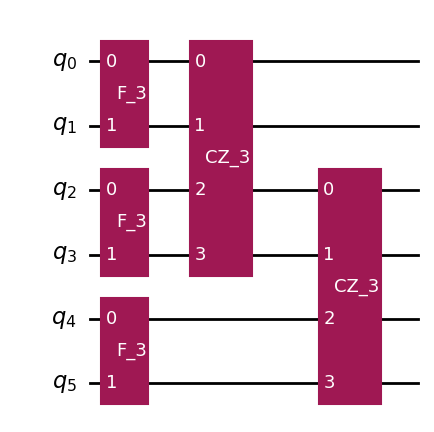

In [27]:
ghz_qc.draw('mpl')

In [83]:
op1, op2 = create_isa_ops(ghz_qc)

In [127]:
pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = prepare_pubs(ghz_qc.decompose().decompose().decompose(), 80, op1, op2, 1)
parts = I_g_stat(est, pub_cuts)
I_g_from_results_with_std(parts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list)

(np.complex128(6.0000000000000275-1.304512053934559e-14j), np.complex128(0j))

In [28]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [29]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-16 13:24:07,190: Default instance not set. Searching all available instances.


In [30]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [31]:
qc_isa = pm.run(ghz_qc)
op_isa, op2_isa = create_isa_ops(qc_isa)

In [33]:
len(op_isa[0])

12

In [141]:
pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = prepare_pubs(qc_isa, 80, op_isa, op2_isa, 1)

In [ ]:
def prepare_chsh(start, stop, resolution, qc):
    theta_list = np.linspace(start, stop, resolution)

    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    # ry02_list = [Ry01(theta) for theta in theta_list]
    # ry02_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry02_list]

    for ry in ry01_qc_list:
        ry.name = "Ry01"

    oplist1 = []
    oplist2 = []

    qc01_list = []
    for ry in ry01_qc_list:
        qctemp = qc.copy()
        qctemp.append(ry, [0, 1])
        #qctemp.append(ry[1], [2, 3])
        qctemp_isa = pm.run(qctemp)
        print(qctemp_isa.depth())
        op1, op2 = create_isa_ops(qctemp_isa)
        oplist1.append(op1)
        oplist2.append(op2)
        qc01_list.append(qctemp_isa)

    return qc01_list, theta_list, oplist1, oplist2

def chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div):
    pub_cuts_list = []
    n_list_list = []
    m_list_list = []
    l_list_list = []

    ncc_list_list = []
    mcc_list_list = []
    lcc_list_list = []

    for qc, op1, op2 in zip(qc01_list, oplist, oplist2):
        pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = prepare_pubs(qc, shots, op1, op2, div)
        pub_cuts_list.append(pub_cuts)
        n_list_list.append(n_list)
        m_list_list.append(m_list)
        l_list_list.append(l_list)
        ncc_list_list.append(ncc_list)
        mcc_list_list.append(mcc_list)
        lcc_list_list.append(lcc_list)

    return pub_cuts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list

def chsh_jobs(est, pub_cuts_list, res):
    parts_list = []

    for pub_cuts, k in zip(pub_cuts_list, range(len(pub_cuts_list))):
        parts = I_g_stat(est, pub_cuts, k, res)
        parts_list.append(parts)

    return parts_list


def chsh_results(parts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list):
    igval_list = []
    stds_list = []

    for parts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list in zip(parts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list):
        ig, stds = I_g_from_results_with_std(parts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list)
        print(ig)
        igval_list.append(ig)
        stds_list.append(np.abs(stds))

    return igval_list, stds_list

def chsh_plot(igval_list, stds_list, theta_list):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        theta_list / np.pi,
        np.real(igval_list),
        yerr=stds_list,
        fmt="o-",                
        capsize=5,                
        color="red",
        label="Ry01"
    )
    ax.axhline(y=5.6381, linestyle="--")
    ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
    plt.xlabel("Theta")
    plt.ylabel("Imax")
    plt.legend()
    plt.show()

In [64]:
def chsh_pub_cuts(
    qc01_list, oplist, oplist2, shots, div,
    order_base=None,
    require_cc_coverage=False,
    order_base_cc=None,
    max_extra_iters=100_000
):
    pub_cuts_list = []
    n_list_list = []
    m_list_list = []
    l_list_list = []

    ncc_list_list = []
    mcc_list_list = []
    lcc_list_list = []

    for qc, op1, op2 in zip(qc01_list, oplist, oplist2):
        pub_cuts, n_list, m_list, l_list, ncc_list, mcc_list, lcc_list = prepare_pubs(
            qc, shots, op1, op2, div,
            order_base=order_base,
            require_cc_coverage=require_cc_coverage,
            order_base_cc=order_base_cc,
            max_extra_iters=max_extra_iters
        )
        pub_cuts_list.append(pub_cuts)
        n_list_list.append(n_list)
        m_list_list.append(m_list)
        l_list_list.append(l_list)
        ncc_list_list.append(ncc_list)
        mcc_list_list.append(mcc_list)
        lcc_list_list.append(lcc_list)

    return pub_cuts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list


In [34]:
from itertools import combinations_with_replacement

In [60]:
def prepare_chsh(start, stop, resolution, qc):
    theta_list = np.linspace(start, stop, resolution)

    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    # ry01_list2 = [Ry01(theta) for theta in theta_list]
    # ry01_qc_list2 = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list2]

    # for ry, ry2 in zip(ry01_qc_list, ry01_qc_list2):
    #     ry.name = "Ry01"
    #     ry2.name = "Ry01"

    qc01_list = []
    for ry in ry01_qc_list:
        qctemp = qc.copy()
        qctemp.append(ry, [0, 1])
        #qctemp.append(ry[1], [2, 3])
        # if pm is not None:
        qctemp = pm.run(qctemp)
        # if trans is not None and backend is not None:
        #     qctemp = trans(qctemp, backend)
        qc01_list.append(qctemp.decompose().decompose().decompose())


    #tutaj jest qc01_list[0] zmieniam na qc01_list
    oplist, oplist2 = create_isa_ops(qc01_list)

    return qc01_list, theta_list, oplist, oplist2

In [53]:
def chsh(start, stop, resolution, est, qc, shots, div, session=False):
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)
    pub_cuts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div)
    if session:
        with Session(backend=backend) as session:
            est = Estimator()
            est.options.default_shots = 100
            est.resilience_level = 2

            parts_list = chsh_jobs(est, pub_cuts_list, resolution)

        print("End of session")
    else:
        parts_list = chsh_jobs(est, pub_cuts_list, resolution)
    igval_list, stds_list = chsh_results(parts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list)
    chsh_plot(igval_list, stds_list, theta_list)
    return igval_list, stds_list, theta_list

In [37]:
qc01_list, theta_list, oplist, oplist2 = prepare_chsh(-1, 1, 1, ghz_qc)
pub_cuts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, 20, 1)

132


In [229]:
def chsh(
    start, stop, resolution, est, qc, shots, div, session=False,
    order_base=None,
    require_cc_coverage=False,
    order_base_cc=None,
    max_extra_iters=150
):
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)

    pub_cuts_list, n_list_list, m_list_list, l_list_list, ncc_list_list, mcc_list_list, lcc_list_list = chsh_pub_cuts(
        qc01_list, oplist, oplist2, shots, div,
        order_base=order_base,
        require_cc_coverage=require_cc_coverage,
        order_base_cc=order_base_cc,
        max_extra_iters=max_extra_iters
    )
    if session:
        with Session(backend=backend) as session:
            est = Estimator()
            est.options.default_shots = 400
            est.options.resilience_level = 2
            parts_list = chsh_jobs(est, pub_cuts_list, resolution)
        print("End of session")
    else:
        parts_list = chsh_jobs(est, pub_cuts_list, resolution)

    igval_list, stds_list = chsh_results(
        parts_list, n_list_list, m_list_list, l_list_list,
        ncc_list_list, mcc_list_list, lcc_list_list
    )

    chsh_plot(igval_list, stds_list, theta_list)
    return igval_list, stds_list, theta_list, [n_list_list, m_list_list, l_list_list,
        ncc_list_list, mcc_list_list, lcc_list_list]

In [147]:
est = AerEstimator()

In [148]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [29]:
order_base = [
    (0,0,0), (1,0,0), (2,0,0),
    (0,1,0), (1,1,0), (2,1,0),
    (0,2,0), (1,2,0), (2,2,0),
    (0,0,1), (1,0,1), (2,0,1),
]

In [31]:
est = AerEstimator()

111
96
85
96
125
1 of 5, Jobs num: 1
1 of 5, Jobs num: 2
2 of 5, Jobs num: 1
2 of 5, Jobs num: 2
3 of 5, Jobs num: 1
3 of 5, Jobs num: 2
4 of 5, Jobs num: 1
4 of 5, Jobs num: 2
5 of 5, Jobs num: 1
5 of 5, Jobs num: 2
(-1.3322676295501878e-15+6.106226635438361e-16j)
(3.138071187457711-5.648259637780484e-15j)
(6.000000000000018-1.16157083951407e-14j)
(3.138071187457708-6.494804694057166e-15j)
(1.0699774399824946e-14+7.216449660063518e-16j)


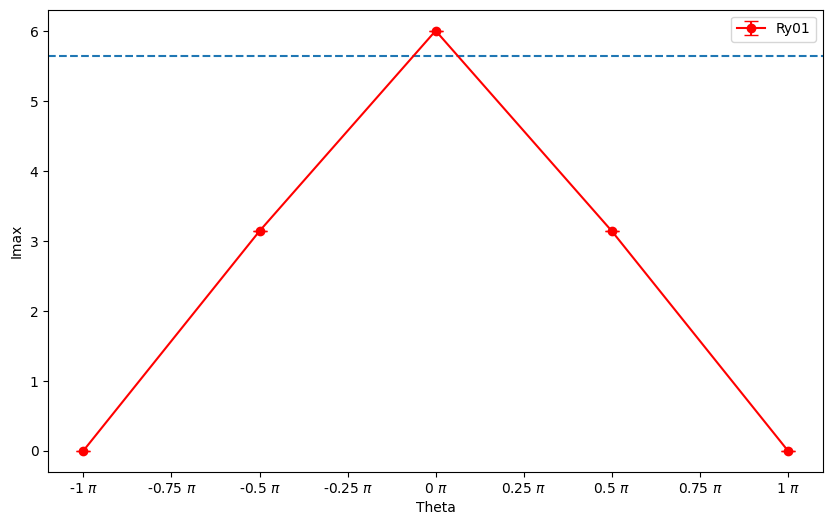

In [69]:
igvals, stds, thetas = chsh(-1*np.pi, 1*np.pi, 5, est, ghz_qc, 80, 2)

112
96
95
113
96
1 of 5, Jobs num: 1
1 of 5, Jobs num: 2
1 of 5, Jobs num: 3
1 of 5, Jobs num: 4
1 of 5, Jobs num: 5
2 of 5, Jobs num: 1
2 of 5, Jobs num: 2
2 of 5, Jobs num: 3
2 of 5, Jobs num: 4
2 of 5, Jobs num: 5
3 of 5, Jobs num: 1
3 of 5, Jobs num: 2
3 of 5, Jobs num: 3
3 of 5, Jobs num: 4
3 of 5, Jobs num: 5
4 of 5, Jobs num: 1
4 of 5, Jobs num: 2
4 of 5, Jobs num: 3
4 of 5, Jobs num: 4
4 of 5, Jobs num: 5
5 of 5, Jobs num: 1
5 of 5, Jobs num: 2
5 of 5, Jobs num: 3
5 of 5, Jobs num: 4
5 of 5, Jobs num: 5
(5.605017017649052-1.0699774399824946e-14j)
(5.899552947464795-1.2122247650125928e-14j)
(6.000000000000011-1.1129985821867194e-14j)
(5.899552947464794-1.1823875212257917e-14j)
(5.605017017649066-1.1955714196432154e-14j)


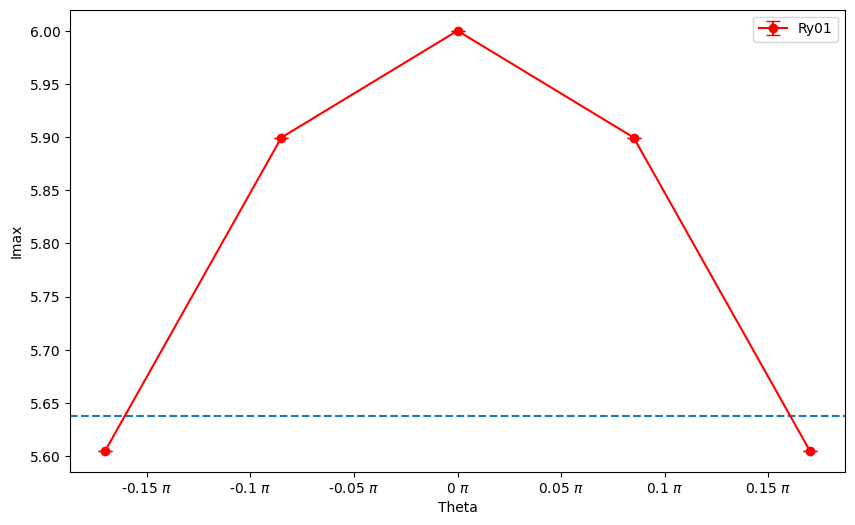

In [70]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 5, est, ghz_qc, 80, 5)

96
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
1 of 1, Jobs num: 3
(5.60501701764907-1.0720591081536668e-14j)


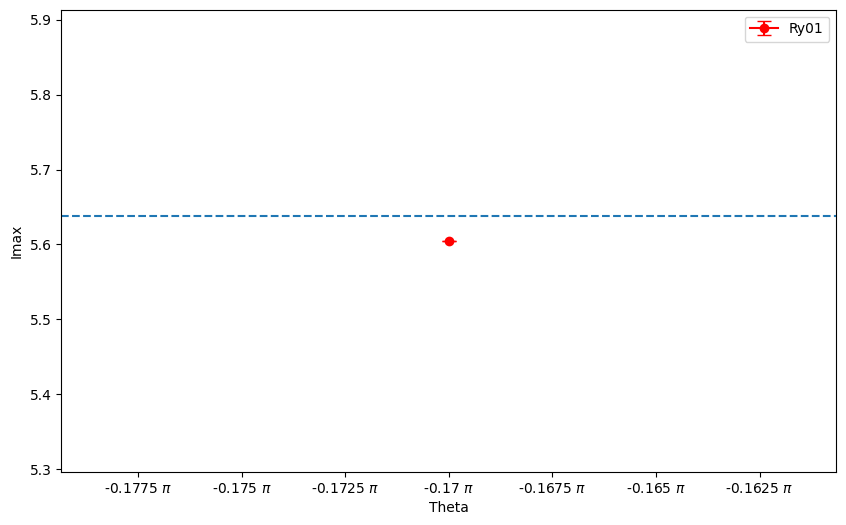

In [114]:
igvals, stds, thetas, rand_list, parts_list = chsh(-0.17*np.pi, 0.17*np.pi, 1, est, ghz_qc, 80, 3, session=False)

In [160]:
p1 = []
p2 = []
p3 = []

for i in parts_list[0][0].result():
    p1.append(i.data.evs)

for i in parts_list[0][1].result():
    p2.append(i.data.evs)

for i in parts_list[0][2].result():
    p3.append(i.data.evs)

In [172]:
p11 = []
p12 = []
p13 = []
p14 = []

for i in p1:
    if i[0].round(4) not in p11:
        p11.append(i[0].round(4))
    if i[1].round(4) in p12:
        p12.append(i[1].round(4))
    if i[2].round(4) in p13:
        p11.append(i[2].round(4))
    if i[3].round(4) in p14:
        p12.append(i[3].round(4))

In [174]:
set(p11)

{np.float64(-0.425),
 np.float64(-0.169),
 np.float64(-0.1673),
 np.float64(0.399),
 np.float64(0.5932),
 np.float64(0.594)}

In [182]:
real1 = [0.5685790213016293, 0.5685790213016287, 0.568579021301629, -0.19746542181734966, 0.5685790213016293, -0.3711135994842796, 0.5685790213016291, -0.19746542181735063, -0.3711135994842787, -0.19746542181734966, 0.5685790213016292, -0.37111359948427947]

im1 = [0.10025582212029027, 0.10025582212029055, 0.10025582212029008, -0.542531787566249, 0.10025582212028966, 0.44227596544595915, 0.10025582212028969, -0.5425317875662488, 0.44227596544596004, -0.5425317875662491, 0.1002558221202897, 0.44227596544595915]


In [178]:
I_g_cor(ghz_qc)

Print ev ops:
(1.0000000000000004-1.942890293094024e-16j)
(0.5000000000000001-7.216449660063518e-16j)
(1.0000000000000002-2.4424906541753444e-15j)
(0.5000000000000001-7.216449660063518e-16j)
Print evs:
(0.5685790213016293+0.10025582212029027j)
(0.5685790213016287+0.10025582212029055j)
(0.568579021301629+0.10025582212029008j)
(-0.19746542181734966-0.542531787566249j)
(0.5685790213016293+0.10025582212028966j)
(-0.3711135994842796+0.44227596544595915j)
(0.5685790213016291+0.10025582212028969j)
(-0.19746542181735063-0.5425317875662488j)
(-0.3711135994842787+0.44227596544596004j)
(-0.19746542181734966-0.5425317875662491j)
(0.5685790213016292+0.1002558221202897j)
(-0.37111359948427947+0.44227596544595915j)
-----------------------
Print ev ops:
(1-3.885780586188048e-16j)
(0.5000000000000001-1.3322676295501878e-15j)
(1.0000000000000007-4.551914400963142e-15j)
(0.5000000000000001-1.3322676295501878e-15j)
Print evs:
(0.568579021301629-0.1002558221202906j)
(0.5685790213016289-0.10025582212029094j

np.complex128(6.000000000000002-1.1657341758564144e-14j)

96
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[        nan  0.56857902  0.44227597 -0.10025582]
EVS OK
EVS NaN
[        nan  0.56857902  0.10025582 -0.10025582]
EVS OK
EVS NaN
[        nan  0.56857902  0.10025582 -0.10025582]
EVS OK
EVS OK
EVS OK
EVS NaN
[        nan -0.3711136   0.44227597 -0.44227597]
EVS OK
EVS NaN
[        nan -0.19746542  0.10025582  0.54253179]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[        nan  0.56857902  0.10025582 -0.10025582]
EVS OK
EVS NaN
[        nan -0.19746542  0.44227597  0.54253179]
EVS OK
EVS OK
EVS NaN
[        nan -0.19746542 -0.54253179  0.54253179]
EVS OK
EVS OK
EVS OK
EVS NaN
[        nan  0.56857902  0.10025582 -0.10025582]
EVS NaN
[        nan  0.56857902 -0.54253179 -0.10025582]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[        nan -0.3711136  -0.54253179 -0.44227597]
EVS OK
EVS NaN
[        nan  0.5

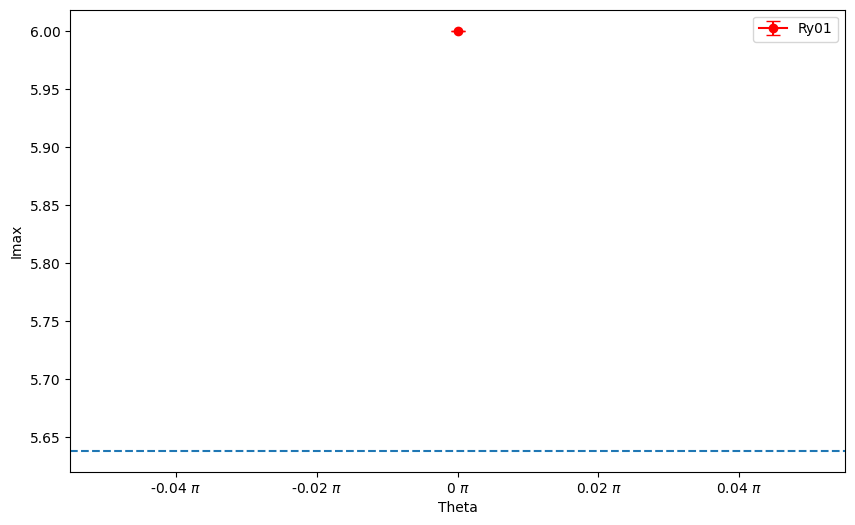

In [230]:
igvals, stds, thetas, rand_list = chsh(0, 1, 1, est, ghz_qc, 80, 2, session=False)

95
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
1 of 1, Jobs num: 3
1 of 1, Jobs num: 4
End of session
EVS OK
EVS NaN
[nan nan nan nan]
EVS OK
EVS OK
EVS OK
EVS NaN
[nan nan nan nan]
EVS OK
EVS OK
EVS NaN
[        nan  0.63297137         nan -0.02717514]
EVS OK
EVS OK
EVS NaN
[       nan 0.50687896        nan 0.00531039]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[nan nan nan nan]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[nan nan nan nan]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS NaN
[0.71236082        nan 0.06744205        nan]
EVS OK
EVS NaN
[        nan  0.61393842         nan -0.10199354]
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
EVS OK
(5.9604078013386665-0.013898462948830723j)


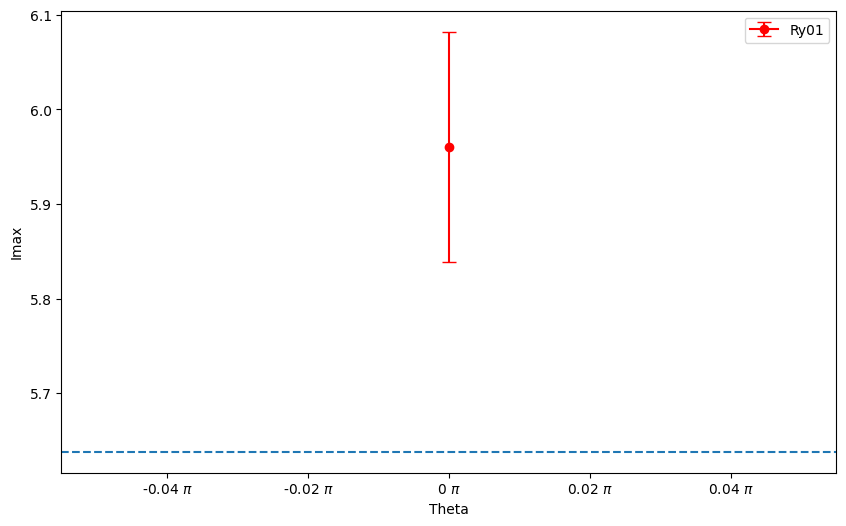

In [233]:
igvals, stds, thetas, rand_list = chsh(0, 1, 1, est, ghz_qc, 80, 4, session=True)

In [234]:
igvals

[np.complex128(5.9604078013386665-0.013898462948830723j)]

In [235]:
stds

[np.float64(0.12182166648161227)]

In [ ]:
from itertools import chain
import csv
from qiskit_ibm_runtime import QiskitRuntimeService


def read_job_ids_from_csv(path: str) -> list[str]:
    """
    Oczekuje nagłówka z kolumną 'JobId' (jak w Twoim pliku).
    Zwraca listę JobId w TEJ SAMEJ kolejności, w jakiej są w CSV.
    """
    job_ids: list[str] = []
    with open(path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if "JobId" not in reader.fieldnames:
            raise ValueError(f"W pliku {path} nie ma kolumny 'JobId'. Znalezione: {reader.fieldnames}")
        for row in reader:
            jid = (row.get("JobId") or "").strip()
            if jid:
                job_ids.append(jid)
    return job_ids


def chunked(seq, n: int):
    return [seq[i:i+n] for i in range(0, len(seq), n)]


def fetch_results_grouped(job_ids: list[str], group_size: int = 10, *, channel=None, instance=None):
    """
    Zwraca:
      - res_groups_raw: lista G grup; każda to lista `group_size` wyników .result() (po jednym na job),
      - res_groups_flat: to samo, ale spłaszczone jeśli pojedynczy job zwraca listę (np. kilka pub_cuts).
    """
    service = (
        QiskitRuntimeService(channel=channel, instance=instance)
        if (channel or instance) else
        QiskitRuntimeService()
    )

    groups = chunked(job_ids, group_size)
    res_groups_raw, res_groups_flat = [], []

    for gi, group in enumerate(groups):
        print(f"\n== Group {gi} ({len(group)} jobs) ==")
        group_raw = []
        for jid in group:
            job = service.job(jid)
            try:
                st = getattr(job.status(), "name", str(job.status()))
            except Exception:
                st = "unknown"
            print(f"[grp{gi}] fetching {jid} (status={st})")
            r = job.result()  # blokująco
            group_raw.append(r)


        if all(isinstance(r, list) for r in group_raw):
            group_flat = list(chain.from_iterable(group_raw))
        else:
            group_flat = group_raw

        res_groups_raw.append(group_raw)
        res_groups_flat.append(group_flat)

    return res_groups_raw, res_groups_flat


CSV_PATH = "session-4c2bced4-564e-46aa-847f-9ee83a6f637b-jobs.csv" 
job_ids = read_job_ids_from_csv(CSV_PATH)
print(f"Znaleziono {len(job_ids)} JobId w CSV.")


res_groups_raw, res_groups_flat = fetch_results_grouped(job_ids, group_size=80)



Znaleziono 3 JobId w CSV.


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-17 03:23:50,392: Default instance not set. Searching all available instances.



== Group 0 (3 jobs) ==
[grp0] fetching d3oocsbgrqts7383mso0 (status=DONE)
[grp0] fetching d3oocqrnquss73e4pjmg (status=DONE)
[grp0] fetching d3ooco3grqts7383msjg (status=DONE)


In [93]:
res_groups_raw[0][2][26].data.evs_noise_factors

array([[ 0.52847245,  0.40125289,  0.37832248],
       [-0.15357421, -0.09309593, -0.13278158],
       [ 0.11693703,  0.08154044,  0.03020684],
       [ 0.54275839,  0.42591302,  0.33510503]])

In [111]:
raw1 = []
raw2 = []
raw3 = []

In [112]:
for i in res_groups_raw[0][0]:
    print(i.data.evs)

[ 0.35461801  0.5279784  -0.11933985 -0.1130212 ]
[-0.12266699  0.61186576 -0.53486682 -0.19469491]
[-0.11480903  0.43530518 -0.57215319  0.03945488]
[ 0.60491059 -0.2569982   0.10501524  0.51214609]
[ 0.40793991 -0.08657169 -0.03149686  0.4932443 ]
[-0.44814314  0.58085733  0.36464579 -0.12668009]
[-0.07189712 -0.24457731 -0.65547768 -0.41691561]
[-0.37186751  0.63074316  0.45549652 -0.1080178 ]
[-0.16375711  0.36561457 -0.53157745  0.0596401 ]
[-0.34112482  0.36326057  0.4603142   0.10124156]
[ 0.6532238  -0.14019982  0.18263552 -0.37589765]
[nan nan nan nan]
[ 0.4889554   0.4889554  -0.01777294  0.01777294]
[-0.25817439 -0.26780132  0.37964734  0.51031765]
[ 0.55840618  0.58896636  0.16132873 -0.27228851]
[ 0.58602998  0.58602998  0.09898201 -0.09898201]
[-0.14268463 -0.14268463 -0.54959965  0.54959965]
[-0.04390808  0.40382384 -0.61304458  0.04528297]
[ 0.57851594 -0.35730768  0.13275765 -0.40775698]
[ 0.51873757 -0.1937888   0.13467249  0.58913101]
[ 0.61497352 -0.16063017  0.1715

In [187]:
np.isnan(res_groups_raw[0][0][11].data.evs) is np.True_

False

In [188]:
res_groups_raw[0][0][11].data.evs

array([nan, nan, nan, nan])

In [97]:
for i in res_groups_raw[0][1]:
    print(i.data.evs)

[ 0.58937147  0.54459835  0.124632   -0.20248642]
[-0.11642591  0.46560655  0.3902583  -0.01942859]
[-0.10644583 -0.18056756  0.45840986  0.61604516]
[ 0.44908312  0.54833558 -0.01144239 -0.10046502]
[ 0.5111138   0.58353692  0.14858579 -0.13581702]
[ 0.25642087  0.6668336  -0.04553996 -0.17417257]
[-0.0972619  -0.0972619  -0.49429893  0.49429893]
[ 0.54233647 -0.14733095  0.15126987  0.60645704]
[ 0.45840569  0.60799843 -0.06728855 -0.1995657 ]
[-0.2113183   0.60437476 -0.59219448 -0.07584274]
[-0.16048974 -0.08626606  0.39706389 -0.38839766]
[-0.11481501  0.32899702  0.36043318 -0.00897514]
[ 0.34647115 -0.21334525 -0.01643205 -0.38940353]
[nan nan nan nan]
[-0.11948503  0.52384048 -0.57248051 -0.1650099 ]
[ 0.54980629  0.5887341   0.07293121 -0.12724457]
[-0.05843936  0.61450586 -0.60824204 -0.08117539]
[-0.29191549  0.37509522  0.53860315  0.06952396]
[0.51185034 0.41860518 0.10006372 0.03272531]
[-0.16851297 -0.16851297  0.35284513 -0.35284513]
[-0.1676351  -0.19390407 -0.4618534 

In [101]:
for i in res_groups_raw[0][2]:
    print(i.data.evs)

[-0.22136663  0.59127607  0.41776541 -0.12339402]
[nan nan nan nan]
[ 0.39192121 -0.23709173 -0.10029941 -0.38957354]
[-0.29127536  0.37135538  0.401321   -0.0082789 ]
[0.60991966 0.47460736 0.14867558 0.04446795]
[-0.17113001  0.59849493  0.3885987  -0.21832103]
[-0.16513302  0.41748211  0.30265176  0.00273957]
[-0.09724858 -0.11297531 -0.60847306  0.5565024 ]
[-0.20192382  0.60094364  0.33234362 -0.13565072]
[ 0.3425366  -0.24205828 -0.00917102  0.58465435]
[ 0.5554473   0.5554473   0.16818129 -0.16818129]
[ 0.4865322  -0.2427823   0.12332084 -0.29357922]
[ 0.29654305  0.60087973 -0.06321075 -0.18198529]
[ 0.56175296 -0.18832971  0.14457726  0.58135974]
[ 0.53476222  0.53476222  0.18625879 -0.18625879]
[ 0.65370168 -0.36762481  0.1205614  -0.5390206 ]
[-0.18817017  0.64311931  0.39379161 -0.17247637]
[-0.1010454  -0.27728459  0.3487666   0.6049242 ]
[ 0.61121149  0.53571062  0.14339953 -0.15636622]
[-0.19522453  0.01833954 -0.64450381  0.5308273 ]
[ 0.35844258  0.64247374  0.00692588

In [ ]:
from itertools import chain
import csv
from qiskit_ibm_runtime import QiskitRuntimeService

def read_job_ids_from_csv(path: str) -> list[str]:
    """
    Oczekuje nagłówka z kolumną 'JobId' (jak w Twoim pliku).
    Zwraca listę JobId w TEJ SAMEJ kolejności, w jakiej są w CSV.
    """
    job_ids: list[str] = []
    with open(path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if "JobId" not in reader.fieldnames:
            raise ValueError(f"W pliku {path} nie ma kolumny 'JobId'. Znalezione: {reader.fieldnames}")
        for row in reader:
            jid = (row.get("JobId") or "").strip()
            if jid:
                job_ids.append(jid)
    return job_ids


def chunked(seq, n: int):
    return [seq[i:i+n] for i in range(0, len(seq), n)]


def fetch_results_grouped(job_ids: list[str], group_size: int = 10, *, channel=None, instance=None):
    """
    Zwraca:
      - res_groups_raw: lista G grup; każda to lista `group_size` wyników .result() (po jednym na job),
      - res_groups_flat: to samo, ale spłaszczone jeśli pojedynczy job zwraca listę (np. kilka pub_cuts).
    """
    service = (
        QiskitRuntimeService(channel=channel, instance=instance)
        if (channel or instance) else
        QiskitRuntimeService()
    )

    groups = chunked(job_ids, group_size)
    res_groups_raw, res_groups_flat = [], []

    for gi, group in enumerate(groups):
        print(f"\n== Group {gi} ({len(group)} jobs) ==")
        group_raw = []
        for jid in group:
            job = service.job(jid)
            try:
                st = getattr(job.status(), "name", str(job.status()))
            except Exception:
                st = "unknown"
            print(f"[grp{gi}] fetching {jid} (status={st})")
            r = job.result()  
            group_raw.append(r)


        if all(isinstance(r, list) for r in group_raw):
            group_flat = list(chain.from_iterable(group_raw))
        else:
            group_flat = group_raw

        res_groups_raw.append(group_raw)
        res_groups_flat.append(group_flat)

    return res_groups_raw, res_groups_flat


CSV_PATH = "session-73d07a9e-3c44-4c4f-8504-c1fdec06bb4f-jobs.csv"  
job_ids = read_job_ids_from_csv(CSV_PATH)
print(f"Znaleziono {len(job_ids)} JobId w CSV.")


res_groups_raw2, res_groups_flat2 = fetch_results_grouped(job_ids, group_size=80)



Znaleziono 5 JobId w CSV.


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-17 03:44:59,502: Default instance not set. Searching all available instances.



== Group 0 (5 jobs) ==
[grp0] fetching d3onr13grqts7383mcdg (status=DONE)
[grp0] fetching d3onr05q5lhs73bau8bg (status=DONE)
[grp0] fetching d3onqv3grqts7383mcag (status=DONE)
[grp0] fetching d3onqu3grqts7383mc9g (status=DONE)
[grp0] fetching d3onqstq5lhs73bau88g (status=DONE)


In [125]:
for i in res_groups_raw2[0][1]:
    print(i.data.evs)

[ 0.3951949   0.3951949  -0.18124434  0.18124434]
[-0.1716712   0.40640583  0.47157699 -0.03424724]
[ 0.43350754  0.48024331 -0.07037487 -0.16253237]
[-0.32085569  0.70670132  0.25865345  0.07622961]
[-0.02992487 -0.17684251 -0.82989442 -0.38890002]
[-0.21469173  0.61176813 -0.55549713 -0.13249744]
[-0.05527156 -0.11028875 -0.45503922  0.5477828 ]
[ 0.4691249  -0.16231315  0.3978765   0.41038565]
[nan nan nan nan]
[ 0.53385572         nan -0.02592275         nan]
[nan nan nan nan]
[-0.17694214 -0.17694214 -0.48449082  0.48449082]
[-0.20309856 -0.47436858 -0.77101494 -0.51180544]
[-0.18191491  0.6081575  -0.71690376 -0.05081863]
[ 0.64745632  0.05673237  0.09461654 -0.2827306 ]
[-0.1967193   0.54381331  0.48193162 -0.25384193]


In [126]:
for i in res_groups_raw2[0][2]:
    print(i.data.evs)

[nan nan nan nan]
[-0.41625308  0.43058526  0.4090779   0.14320997]
[ 0.64435232 -0.24929066  0.01516731  0.64805284]
[nan nan nan nan]
[-0.44962833 -0.22421153  0.46610754 -0.59459038]
[ 0.30317886  0.54724802 -0.04485122 -0.06414111]
[ 0.74409882  0.55234696  0.24151879 -0.0639274 ]
[-0.44086305  0.57421423  0.44179115  0.08687447]
[ 0.69032084  0.4635354   0.14878623 -0.22689375]
[        nan -0.14226224         nan  0.40593521]
[-0.58422409  0.47919401  0.41705192  0.00884017]
[-0.43009184  0.45493458  0.53543092  0.15706734]
[nan nan nan nan]
[-0.14233796 -0.10583118 -0.49886413 -0.40077923]
[ 0.52704011  0.68079416 -0.11512293 -0.08078309]
[-0.15715749 -0.15715749  0.28050773 -0.28050773]


In [129]:
for i in res_groups_raw2[0][4]:
    print(i.data.evs)

[-0.23845567  0.44806384 -0.49155274  0.11375885]
[ 0.46893074  0.69861449 -0.03030662 -0.21141853]
[-0.27772854 -0.27772854 -0.64837533  0.64837533]
[0.58632192        nan 0.10925299        nan]
[-0.14569449 -0.49423089 -0.62792889 -0.49987371]
[ 0.81653828 -0.26249211  0.13697918 -0.45527203]
[        nan -0.28092449         nan -0.2528494 ]
[nan nan nan nan]
[ 0.50890273 -0.15916629  0.15002372  0.5924602 ]
[ 0.56035913 -0.32550739  0.16595245 -0.46388114]
[ 0.67441214  0.67374774 -0.07426115 -0.16500543]
[-0.25063689  0.45740557 -0.7228937   0.05015301]
[nan nan nan nan]
[0.79256024        nan 0.05864994        nan]
[ 0.58387353  0.65047237  0.21088935 -0.1699823 ]
[nan nan nan nan]


In [19]:
est = AerEstimator()

In [50]:
est = AerEstimator()

In [51]:
igvals, stds, thetas = chsh(-1*np.pi, 1*np.pi, 5, est, ghz_qc.decompose().decompose().decompose(), None, 80, 4)

0 of 5, Jobs num: 1
0 of 5, Jobs num: 2
0 of 5, Jobs num: 3
0 of 5, Jobs num: 4
1 of 5, Jobs num: 1
1 of 5, Jobs num: 2
1 of 5, Jobs num: 3
1 of 5, Jobs num: 4
2 of 5, Jobs num: 1
2 of 5, Jobs num: 2
2 of 5, Jobs num: 3
2 of 5, Jobs num: 4
3 of 5, Jobs num: 1
3 of 5, Jobs num: 2
3 of 5, Jobs num: 3
3 of 5, Jobs num: 4
4 of 5, Jobs num: 1
4 of 5, Jobs num: 2
4 of 5, Jobs num: 3
4 of 5, Jobs num: 4
5 of 5, Jobs num: 1
5 of 5, Jobs num: 2
5 of 5, Jobs num: 3
5 of 5, Jobs num: 4
6 of 5, Jobs num: 1
6 of 5, Jobs num: 2
6 of 5, Jobs num: 3
6 of 5, Jobs num: 4
7 of 5, Jobs num: 1
7 of 5, Jobs num: 2
7 of 5, Jobs num: 3
7 of 5, Jobs num: 4
8 of 5, Jobs num: 1
8 of 5, Jobs num: 2
8 of 5, Jobs num: 3
8 of 5, Jobs num: 4
9 of 5, Jobs num: 1
9 of 5, Jobs num: 2
9 of 5, Jobs num: 3
9 of 5, Jobs num: 4
10 of 5, Jobs num: 1
10 of 5, Jobs num: 2
10 of 5, Jobs num: 3
10 of 5, Jobs num: 4
11 of 5, Jobs num: 1
11 of 5, Jobs num: 2
11 of 5, Jobs num: 3
11 of 5, Jobs num: 4
12 of 5, Jobs num: 1
12 of 5, Jo

In [68]:
np.array(igvals).round(3)

array([-0.   +0.j, -0.   +0.j,  0.   -0.j,  0.   +0.j,  0.   -0.j,
       -0.   +0.j,  1.914-0.j,  3.   -0.j,  1.914-0.j,  0.   -0.j,
       -0.   -0.j,  3.828-0.j,  6.   -0.j,  3.828-0.j,  0.   -0.j,
        0.   -0.j,  1.914-0.j,  3.   -0.j,  1.914-0.j,  0.   -0.j,
       -0.   +0.j, -0.   +0.j,  0.   +0.j,  0.   -0.j,  0.   -0.j])

In [56]:
alfas = np.linspace(-1*np.pi, 1*np.pi, 5)

In [60]:
X, Y = np.meshgrid(alfas / np.pi, alfas / np.pi)

In [63]:
Z = np.real(np.array(igvals).reshape(5, 5))

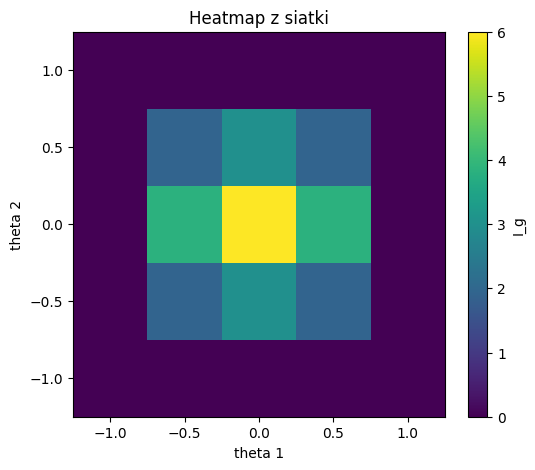

In [64]:
plt.figure(figsize=(6,5))
plt.pcolormesh(X, Y, Z, cmap="viridis", shading="auto")
plt.colorbar(label="I_g")
plt.xlabel("theta 1")
plt.ylabel("theta 2")
plt.title("Heatmap z siatki")
plt.show()

In [25]:
est = AerEstimator()

In [159]:
igvals, stds, thetas = chsh(-0.5*np.pi, 0.5*np.pi, 2, est, ghz_qc.decompose().decompose().decompose(), 80, 2)

1 of 2, Jobs num: 1
1 of 2, Jobs num: 2
2 of 2, Jobs num: 1
2 of 2, Jobs num: 2
3 of 2, Jobs num: 1
3 of 2, Jobs num: 2
4 of 2, Jobs num: 1
4 of 2, Jobs num: 2
(2.003708712566083-3.712308238590367e-15j)
(2.0037087125660853-3.552713678800501e-15j)
(1.9894109729616396-3.573530360512223e-15j)
(1.9894109729616085-4.073130721593543e-15j)


In [39]:
len(igvals)

49

In [46]:
for ig, th in zip(igvals, product(thetas, thetas)):
    print(th[0].round(3), th[1].round(3), ig.round(3))

-1.571 -1.571 (1.914-0j)
-1.571 -1.047 (2.482-0j)
-1.571 -0.524 (2.865-0j)
-1.571 0.0 (3-0j)
-1.571 0.524 (2.865-0j)
-1.571 1.047 (2.482-0j)
-1.571 1.571 (1.914-0j)
-1.047 -1.571 (2.871-0j)
-1.047 -1.047 (3.723-0j)
-1.047 -0.524 (4.297-0j)
-1.047 0.0 (4.5-0j)
-1.047 0.524 (4.297-0j)
-1.047 1.047 (3.723-0j)
-1.047 1.571 (2.871-0j)
-0.524 -1.571 (3.572-0j)
-0.524 -1.047 (4.632-0j)
-0.524 -0.524 (5.346-0j)
-0.524 0.0 (5.598-0j)
-0.524 0.524 (5.346-0j)
-0.524 1.047 (4.632-0j)
-0.524 1.571 (3.572-0j)
0.0 -1.571 (3.828-0j)
0.0 -1.047 (4.964-0j)
0.0 -0.524 (5.73-0j)
0.0 0.0 (6-0j)
0.0 0.524 (5.73-0j)
0.0 1.047 (4.964-0j)
0.0 1.571 (3.828-0j)
0.524 -1.571 (3.572-0j)
0.524 -1.047 (4.632-0j)
0.524 -0.524 (5.346-0j)
0.524 0.0 (5.598-0j)
0.524 0.524 (5.346-0j)
0.524 1.047 (4.632-0j)
0.524 1.571 (3.572-0j)
1.047 -1.571 (2.871-0j)
1.047 -1.047 (3.723-0j)
1.047 -0.524 (4.297-0j)
1.047 0.0 (4.5-0j)
1.047 0.524 (4.297-0j)
1.047 1.047 (3.723-0j)
1.047 1.571 (2.871-0j)
1.571 -1.571 (1.914-0j)
1.571 -1.04

In [47]:
alfas2 = np.linspace(-0.5*np.pi, 0.5*np.pi, 7)
X2, Y2 = np.meshgrid(alfas2, alfas2)
Z2 = np.real(np.array(igvals).reshape(7, 7))

In [43]:
Z2

array([[1.91421356, 2.48205081, 2.86486435, 3.        , 2.86486435,
        2.48205081, 1.91421356],
       [2.87132034, 3.72307621, 4.29729653, 4.5       , 4.29729653,
        3.72307621, 2.87132034],
       [3.57197114, 4.63156986, 5.34590966, 5.59807621, 5.34590966,
        4.63156986, 3.57197114],
       [3.82842712, 4.96410162, 5.72972871, 6.        , 5.72972871,
        4.96410162, 3.82842712],
       [3.57197114, 4.63156986, 5.34590966, 5.59807621, 5.34590966,
        4.63156986, 3.57197114],
       [2.87132034, 3.72307621, 4.29729653, 4.5       , 4.29729653,
        3.72307621, 2.87132034],
       [1.91421356, 2.48205081, 2.86486435, 3.        , 2.86486435,
        2.48205081, 1.91421356]])

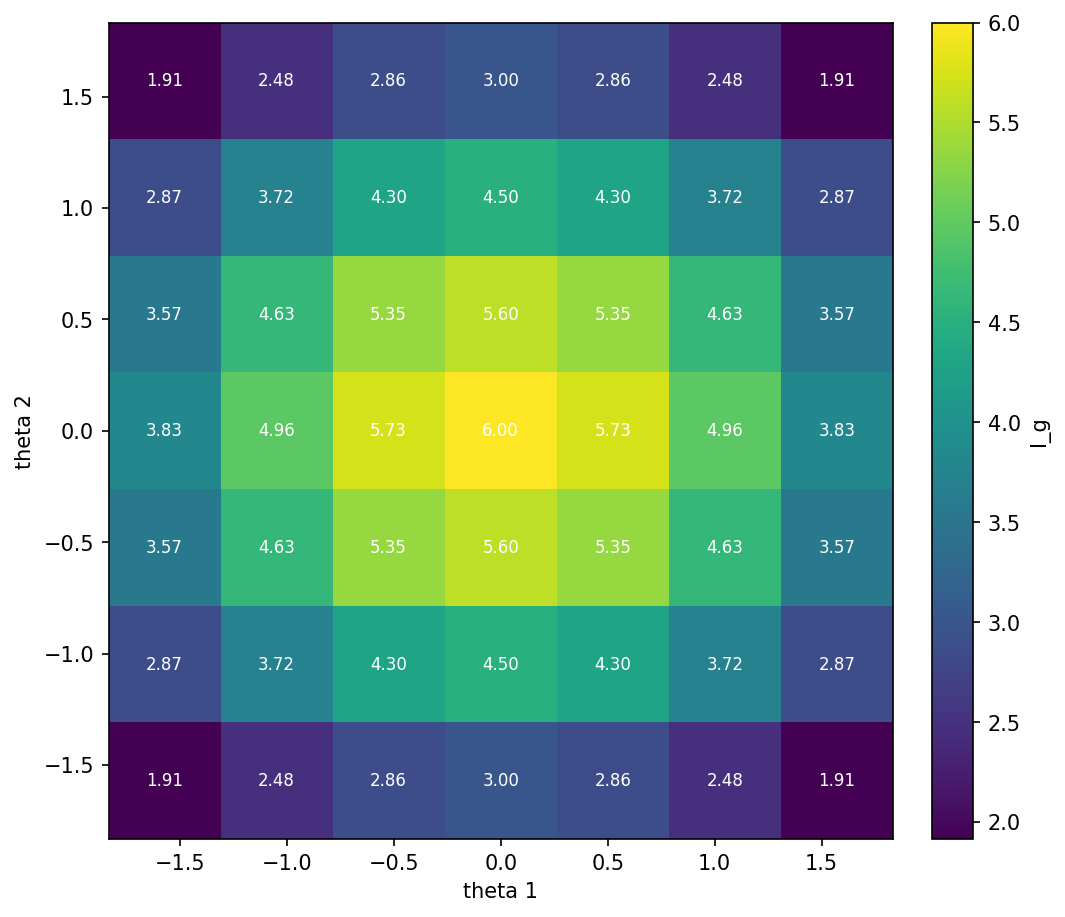

In [ ]:
plt.figure(figsize=(7,6), dpi=150, constrained_layout=True)
plt.pcolormesh(X2, Y2, Z2, cmap="viridis", shading="auto")
plt.colorbar(label="I_g")
plt.xlabel("theta 1")
plt.ylabel("theta 2")

for i in range(len(alfas2)):       # oś Y
    for j in range(len(alfas2)):   # oś X
        plt.text(alfas2[j], alfas2[i], f"{Z2[i,j]:.2f}",
                 ha="center", va="center", color="w", fontsize=8)

plt.show()

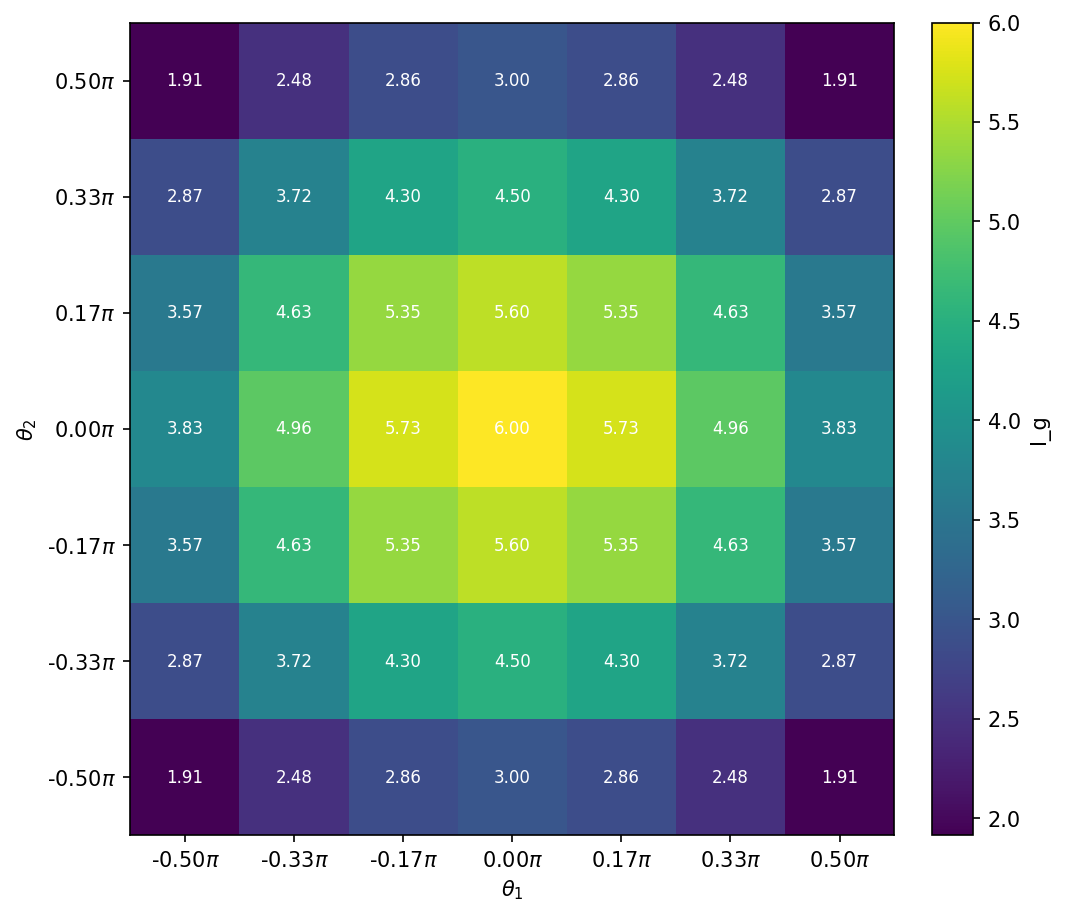

In [ ]:
fig, ax = plt.subplots(figsize=(7,6), dpi=150, constrained_layout=True)
m = ax.pcolormesh(X2, Y2, Z2, cmap="viridis", shading="auto")
fig.colorbar(m, ax=ax, label="I_g")


ax.set_xticks(alfas2)
ax.set_yticks(alfas2)
ax.set_xticklabels([f"{v/np.pi:.2f}$\pi$" for v in alfas2])
ax.set_yticklabels([f"{v/np.pi:.2f}$\pi$" for v in alfas2])
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")

for i in range(len(alfas2)):
    for j in range(len(alfas2)):
        ax.text(alfas2[j], alfas2[i], f"{Z2[i,j]:.2f}",
                ha="center", va="center", color="w", fontsize=8)

plt.show()

In [53]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc.decompose().decompose().decompose(), None, 80, 4)

0 of 49, Jobs num: 1
0 of 49, Jobs num: 2
0 of 49, Jobs num: 3
0 of 49, Jobs num: 4
1 of 49, Jobs num: 1
1 of 49, Jobs num: 2
1 of 49, Jobs num: 3
1 of 49, Jobs num: 4
2 of 49, Jobs num: 1
2 of 49, Jobs num: 2
2 of 49, Jobs num: 3
2 of 49, Jobs num: 4
3 of 49, Jobs num: 1
3 of 49, Jobs num: 2
3 of 49, Jobs num: 3
3 of 49, Jobs num: 4
4 of 49, Jobs num: 1
4 of 49, Jobs num: 2
4 of 49, Jobs num: 3
4 of 49, Jobs num: 4
5 of 49, Jobs num: 1
5 of 49, Jobs num: 2
5 of 49, Jobs num: 3
5 of 49, Jobs num: 4
6 of 49, Jobs num: 1
6 of 49, Jobs num: 2
6 of 49, Jobs num: 3
6 of 49, Jobs num: 4
7 of 49, Jobs num: 1
7 of 49, Jobs num: 2
7 of 49, Jobs num: 3
7 of 49, Jobs num: 4
8 of 49, Jobs num: 1
8 of 49, Jobs num: 2
8 of 49, Jobs num: 3
8 of 49, Jobs num: 4
9 of 49, Jobs num: 1
9 of 49, Jobs num: 2
9 of 49, Jobs num: 3
9 of 49, Jobs num: 4
10 of 49, Jobs num: 1
10 of 49, Jobs num: 2
10 of 49, Jobs num: 3
10 of 49, Jobs num: 4
11 of 49, Jobs num: 1
11 of 49, Jobs num: 2
11 of 49, Jobs num: 3
11 of 

In [54]:
alfas3 = np.linspace(-0.17*np.pi, 0.17*np.pi, 7)
X3, Y3 = np.meshgrid(alfas3, alfas3)
Z3 = np.real(np.array(igvals).reshape(7, 7))

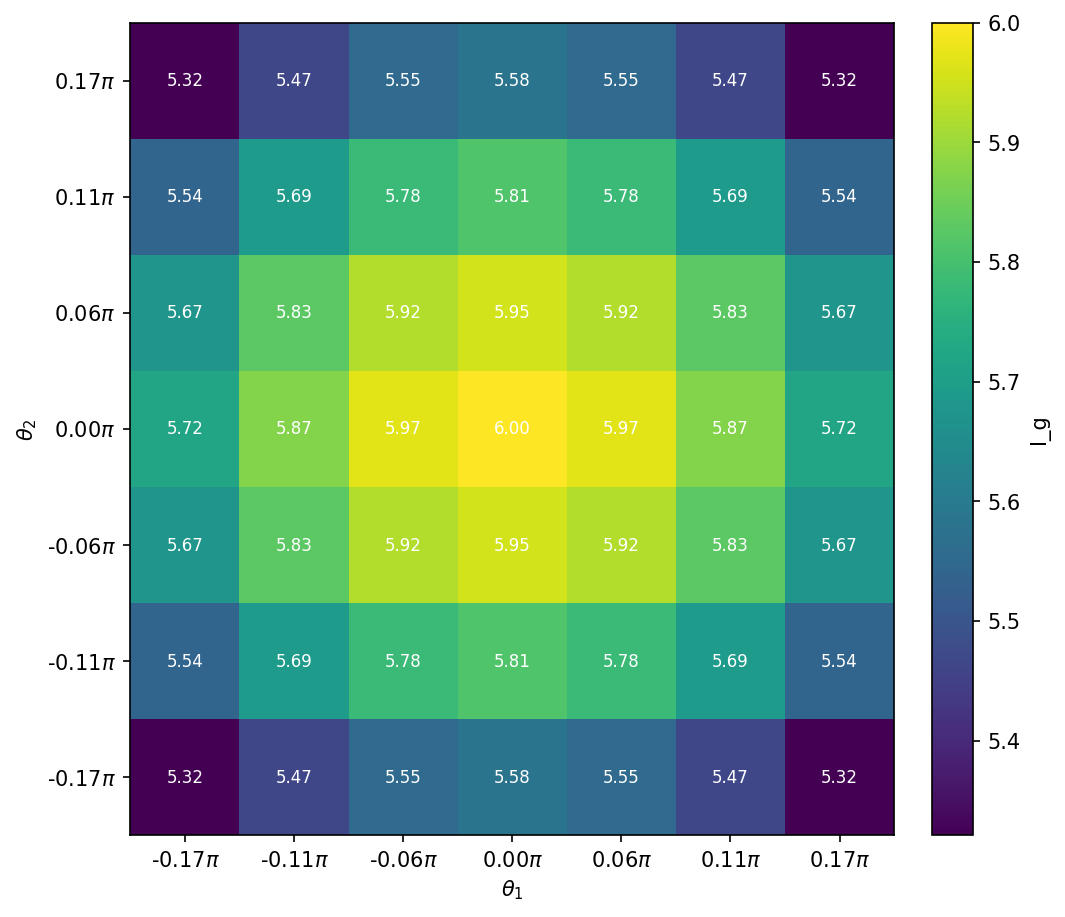

In [ ]:
fig, ax = plt.subplots(figsize=(7,6), dpi=150, constrained_layout=True)
m = ax.pcolormesh(X3, Y3, Z3, cmap="viridis", shading="auto")
fig.colorbar(m, ax=ax, label="I_g")

ax.set_xticks(alfas3)
ax.set_yticks(alfas3)
ax.set_xticklabels([f"{v/np.pi:.2f}$\pi$" for v in alfas3])
ax.set_yticklabels([f"{v/np.pi:.2f}$\pi$" for v in alfas3])
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")


for i in range(len(alfas3)):
    for j in range(len(alfas3)):
        ax.text(alfas3[j], alfas3[i], f"{Z3[i,j]:.2f}",
                ha="center", va="center", color="w", fontsize=8)

plt.show()

In [56]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 5, est, ghz_qc, 80, 8)

115
120
109
135
136
115
121
109
114
125
124
115
102
136
115
117
113
109
125
103
117
120
91
114
114
1 of 5, Jobs num: 1
1 of 5, Jobs num: 2
1 of 5, Jobs num: 3
1 of 5, Jobs num: 4
1 of 5, Jobs num: 5
1 of 5, Jobs num: 6
1 of 5, Jobs num: 7
1 of 5, Jobs num: 8
2 of 5, Jobs num: 1
2 of 5, Jobs num: 2
2 of 5, Jobs num: 3
2 of 5, Jobs num: 4
2 of 5, Jobs num: 5
2 of 5, Jobs num: 6
2 of 5, Jobs num: 7
2 of 5, Jobs num: 8
3 of 5, Jobs num: 1
3 of 5, Jobs num: 2
3 of 5, Jobs num: 3
3 of 5, Jobs num: 4
3 of 5, Jobs num: 5
3 of 5, Jobs num: 6
3 of 5, Jobs num: 7
3 of 5, Jobs num: 8
4 of 5, Jobs num: 1
4 of 5, Jobs num: 2
4 of 5, Jobs num: 3
4 of 5, Jobs num: 4
4 of 5, Jobs num: 5
4 of 5, Jobs num: 6
4 of 5, Jobs num: 7
4 of 5, Jobs num: 8
5 of 5, Jobs num: 1
5 of 5, Jobs num: 2
5 of 5, Jobs num: 3
5 of 5, Jobs num: 4
5 of 5, Jobs num: 5
5 of 5, Jobs num: 6
5 of 5, Jobs num: 7
5 of 5, Jobs num: 8
6 of 5, Jobs num: 1
6 of 5, Jobs num: 2
6 of 5, Jobs num: 3
6 of 5, Jobs num: 4
6 of 5, Jobs num: 5
6

KeyboardInterrupt: 

0 of 49, Jobs num: 1
0 of 49, Jobs num: 2
0 of 49, Jobs num: 3
0 of 49, Jobs num: 4
1 of 49, Jobs num: 1
1 of 49, Jobs num: 2
1 of 49, Jobs num: 3
1 of 49, Jobs num: 4
2 of 49, Jobs num: 1
2 of 49, Jobs num: 2
2 of 49, Jobs num: 3
2 of 49, Jobs num: 4
3 of 49, Jobs num: 1
3 of 49, Jobs num: 2
3 of 49, Jobs num: 3
3 of 49, Jobs num: 4
4 of 49, Jobs num: 1
4 of 49, Jobs num: 2
4 of 49, Jobs num: 3
4 of 49, Jobs num: 4
5 of 49, Jobs num: 1
5 of 49, Jobs num: 2
5 of 49, Jobs num: 3
5 of 49, Jobs num: 4
6 of 49, Jobs num: 1
6 of 49, Jobs num: 2
6 of 49, Jobs num: 3
6 of 49, Jobs num: 4
(5.71897170083513-5.4262150328554526e-15j)
(5.874064421368852-5.9674487573602164e-15j)
(5.968359869612316-5.037636974236648e-15j)
(5.999999999999993-5.6066262743570405e-15j)
(5.9683598696123115-5.412337245047638e-15j)
(5.874064421368852-5.773159728050814e-15j)
(5.718971700835135-5.287437154777308e-15j)


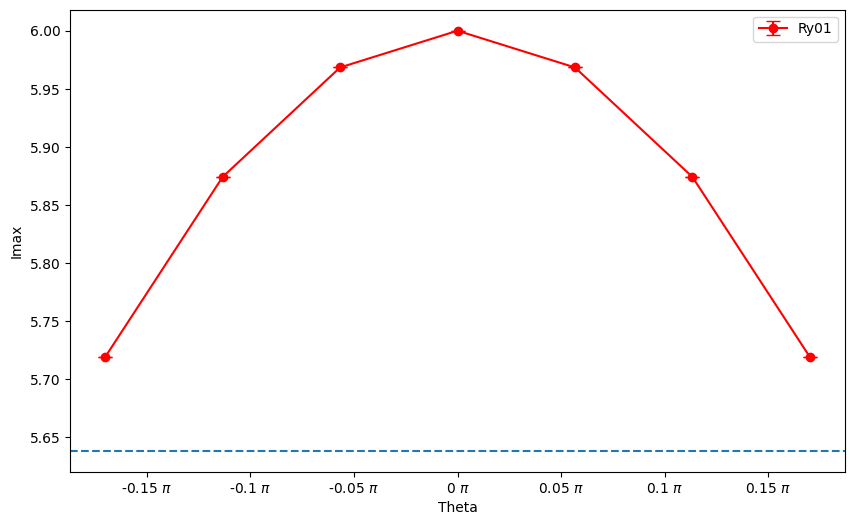

In [64]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, None, 80, 4)

1 of 49, Jobs num: 1
1 of 49, Jobs num: 2
1 of 49, Jobs num: 3
1 of 49, Jobs num: 4
2 of 49, Jobs num: 1
2 of 49, Jobs num: 2
2 of 49, Jobs num: 3
2 of 49, Jobs num: 4
3 of 49, Jobs num: 1
3 of 49, Jobs num: 2
3 of 49, Jobs num: 3
3 of 49, Jobs num: 4
4 of 49, Jobs num: 1
4 of 49, Jobs num: 2
4 of 49, Jobs num: 3
4 of 49, Jobs num: 4
5 of 49, Jobs num: 1
5 of 49, Jobs num: 2
5 of 49, Jobs num: 3
5 of 49, Jobs num: 4
6 of 49, Jobs num: 1
6 of 49, Jobs num: 2
6 of 49, Jobs num: 3
6 of 49, Jobs num: 4
7 of 49, Jobs num: 1
7 of 49, Jobs num: 2
7 of 49, Jobs num: 3
7 of 49, Jobs num: 4
(5.582226081011849-7.08461067588928e-15j)
(5.811845968475689-7.348288644237755e-15j)
(5.952586823907747-7.396860901565105e-15j)
(6.000000000000016-7.591149930874508e-15j)
(5.952586823907742-7.716050021144838e-15j)
(5.811845968475696-7.688294445529209e-15j)
(5.582226081011844-7.0013439490423934e-15j)


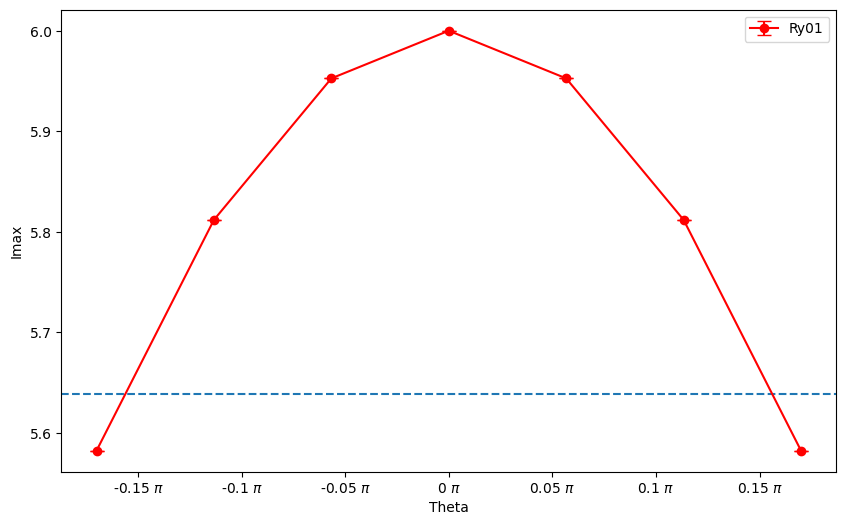

In [81]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 4)

1 of 49, Jobs num: 1
1 of 49, Jobs num: 2
1 of 49, Jobs num: 3
2 of 49, Jobs num: 1
2 of 49, Jobs num: 2
2 of 49, Jobs num: 3
3 of 49, Jobs num: 1
3 of 49, Jobs num: 2
3 of 49, Jobs num: 3
4 of 49, Jobs num: 1
4 of 49, Jobs num: 2
4 of 49, Jobs num: 3
5 of 49, Jobs num: 1
5 of 49, Jobs num: 2
5 of 49, Jobs num: 3
6 of 49, Jobs num: 1
6 of 49, Jobs num: 2
6 of 49, Jobs num: 3
7 of 49, Jobs num: 1
7 of 49, Jobs num: 2
7 of 49, Jobs num: 3
(5.7189717008351515-6.175615574477433e-15j)
(5.874064421368873-7.993605777301127e-15j)
(5.968359869612339-7.93809462606987e-15j)
(6.000000000000011-8.03523914072457e-15j)
(5.968359869612336-7.729927808952652e-15j)
(5.874064421368872-7.868705687030797e-15j)
(5.7189717008351515-6.702971511174383e-15j)


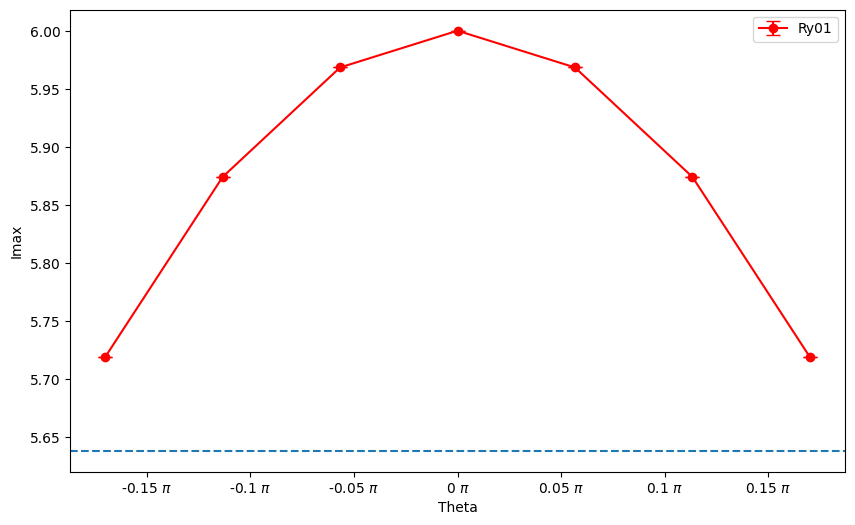

In [83]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 3)

In [43]:
est = AerEstimator()
est.options.default_shots = 100

[0. 1. 2.]
(6.000000000000014-8.368306048112117e-15j)
1 of 9, Jobs num: 1
1 of 9, Jobs num: 2
1 of 9, Jobs num: 3
2 of 9, Jobs num: 1
2 of 9, Jobs num: 2
2 of 9, Jobs num: 3
3 of 9, Jobs num: 1
3 of 9, Jobs num: 2
3 of 9, Jobs num: 3
(6.000000000000014-8.451572774959004e-15j)
(1.1063062705070962e-14+6.633128379313046e-16j)
(6.000000000000007-7.244205235679146e-15j)


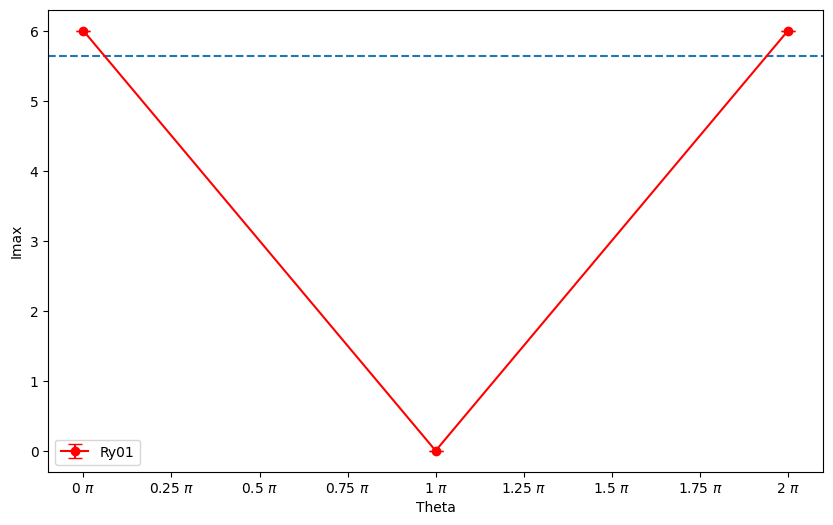

In [75]:
igvals, stds, thetas = chsh(0, 2*np.pi, 3, est, ghz_qc, 60, 3)

In [27]:
isa_ghz = pm.run(ghz_qc)

In [28]:
op1tst, op2tst = create_isa_ops(isa_ghz)

In [29]:
I_g_random(isa_ghz, est, 60, op1tst, op2tst)

np.complex128(6.000000000000014-6.8833827526759706e-15j)

In [48]:
theta_list = np.linspace(0, 2*np.pi, 3)

ry01_list = [Ry01(theta) for theta in theta_list]
ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

for ry in ry01_qc_list:
    ry.name = "Ry01"



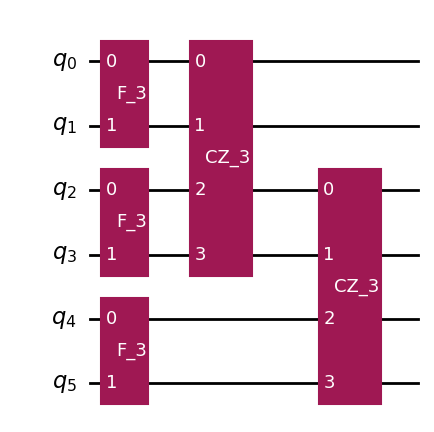

In [61]:
qctemp = ghz_qc.copy()
qctemp.draw('mpl')

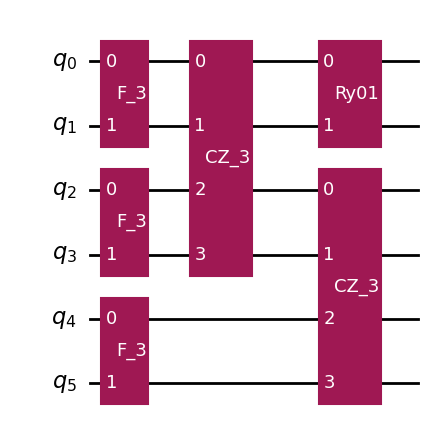

In [63]:
qctemp.append(ry01_qc_list[1], [0, 1])
qctemp.draw('mpl')

In [64]:
qctemp_isa = pm.run(qctemp)

In [65]:
oplist, oplist2 = create_isa_ops(qctemp_isa)

In [60]:
I_g_random(qctemp_isa, est, 60, oplist, oplist2)

np.complex128(6.000000000000016-7.702172233337023e-15j)

In [66]:
I_g_random(qctemp_isa, est, 60, oplist, oplist2)

np.complex128(1.8182900823270803e-14+5.233053819275172e-16j)

In [67]:


qc01_list = []
for ry in ry01_qc_list:
    qctemp = ghz_qc.copy()
    qctemp.append(ry, [0, 1])
    qctemp_isa = pm.run(qctemp)
    qc01_list.append(qctemp_isa)

oplist, oplist2 = create_isa_ops(qc01_list[0])

In [68]:
for qc in qc01_list:
    print(I_g_random(qc, est, 60, oplist, oplist2))

(6.000000000000011-7.854827899222983e-15j)
(1.8075927679574237e-17+4.912996472234992e-18j)
(-2.356476491054014e-17+3.78080491052865e-17j)


In [69]:
for qc in qc01_list:
    print(I_g_random(qc, est, 60, oplist, oplist2))

(6.000000000000011-7.813194535799539e-15j)
(1.8075927679574237e-17+4.912996472234992e-18j)
(-2.356476491054014e-17+3.78080491052865e-17j)


In [71]:
I_g_random(qc01_list[0], est, 60, oplist, oplist2)

np.complex128(6.000000000000011-7.93809462606987e-15j)

In [41]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-16 13:27:03,444: Default instance not set. Searching all available instances.


In [42]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [43]:
est = AerEstimator()
est.options.default_shots = 100

In [46]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 4)

1 of 7, Jobs num: 1
1 of 7, Jobs num: 2
1 of 7, Jobs num: 3
1 of 7, Jobs num: 4
2 of 7, Jobs num: 1
2 of 7, Jobs num: 2
2 of 7, Jobs num: 3
2 of 7, Jobs num: 4
(0.02080173219247415+0.020801732192474175j)
(-0.0043345217918476005+0.004334521791847565j)


In [45]:
igvals

[np.complex128(0.02080173219247415+0.020801732192474175j),
 np.complex128(-0.0043345217918476005+0.004334521791847565j)]

1 of 7, Jobs num: 1
1 of 7, Jobs num: 2
1 of 7, Jobs num: 3
2 of 7, Jobs num: 1
2 of 7, Jobs num: 2
2 of 7, Jobs num: 3
3 of 7, Jobs num: 1
3 of 7, Jobs num: 2
3 of 7, Jobs num: 3
4 of 7, Jobs num: 1
4 of 7, Jobs num: 2
4 of 7, Jobs num: 3
5 of 7, Jobs num: 1
5 of 7, Jobs num: 2
5 of 7, Jobs num: 3
6 of 7, Jobs num: 1
6 of 7, Jobs num: 2
6 of 7, Jobs num: 3
7 of 7, Jobs num: 1
7 of 7, Jobs num: 2
7 of 7, Jobs num: 3
End of session
(4.693998932345366+0.08291209071960101j)
(5.027974321362893-0.0990197194528957j)
(5.195472179994078-0.03111749232719204j)
(5.294753531419612-0.03493963942968505j)
(5.237479262917729-0.04899919109804493j)
(5.028315030824832-0.026013079791458754j)
(4.586935472663389+0.049116755856379j)


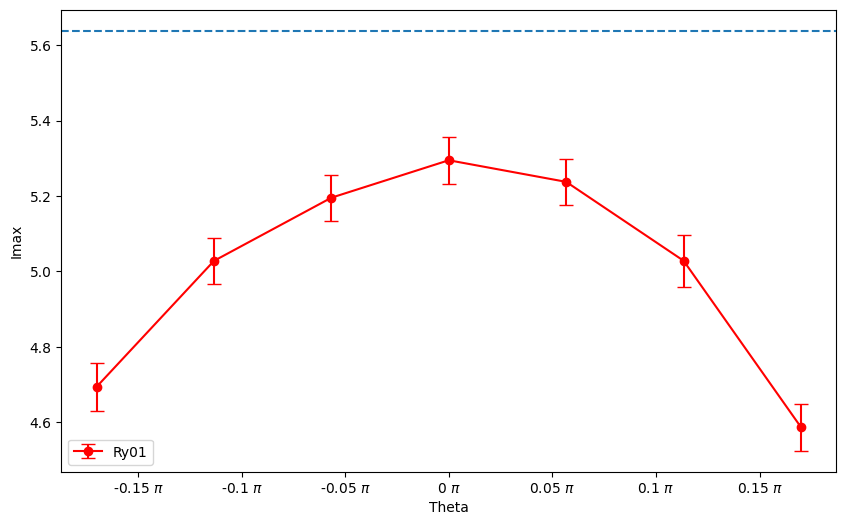

In [91]:
igvals, , stdsthetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 3, session=True)

In [47]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 3, session=False)


1 of 7, Jobs num: 1
1 of 7, Jobs num: 2
1 of 7, Jobs num: 3
2 of 7, Jobs num: 1
2 of 7, Jobs num: 2
2 of 7, Jobs num: 3


ValueError: Brakuje terminów: [(0, 0, 0, 0), (0, 1, 0, 1), (0, 0, 0, 0), (0, 1, 0, 1), (0, 0, 0, 0), (0, 1, 0, 1), (0, 0, 0, 0), (0, 1, 0, 1)]
Dostępne re: [(0, np.int64(0), np.int64(0), np.int64(1)), (0, np.int64(0), np.int64(1), np.int64(0)), (0, np.int64(0), np.int64(2), np.int64(0)), (0, np.int64(1), np.int64(0), np.int64(0)), (0, np.int64(1), np.int64(1), np.int64(0)), (0, np.int64(1), np.int64(2), np.int64(0)), (0, np.int64(2), np.int64(0), np.int64(0)), (0, np.int64(2), np.int64(0), np.int64(1)), (0, np.int64(2), np.int64(1), np.int64(0)), (0, np.int64(2), np.int64(2), np.int64(0)), (1, np.int64(0), np.int64(0), np.int64(0)), (1, np.int64(0), np.int64(0), np.int64(1)), (1, np.int64(0), np.int64(1), np.int64(0)), (1, np.int64(0), np.int64(2), np.int64(0)), (1, np.int64(1), np.int64(0), np.int64(0)), (1, np.int64(1), np.int64(0), np.int64(1)), (1, np.int64(1), np.int64(1), np.int64(0)), (1, np.int64(1), np.int64(2), np.int64(0)), (1, np.int64(2), np.int64(0), np.int64(0)), (1, np.

1 of 7, Jobs num: 1
1 of 7, Jobs num: 2
1 of 7, Jobs num: 3
2 of 7, Jobs num: 1
2 of 7, Jobs num: 2
2 of 7, Jobs num: 3
3 of 7, Jobs num: 1
3 of 7, Jobs num: 2
3 of 7, Jobs num: 3
4 of 7, Jobs num: 1
4 of 7, Jobs num: 2
4 of 7, Jobs num: 3
5 of 7, Jobs num: 1
5 of 7, Jobs num: 2
5 of 7, Jobs num: 3
6 of 7, Jobs num: 1
6 of 7, Jobs num: 2
6 of 7, Jobs num: 3
7 of 7, Jobs num: 1
7 of 7, Jobs num: 2
7 of 7, Jobs num: 3
(5.718971700835148-6.189493362285248e-15j)
(5.874064421368878-7.743805596760467e-15j)
(5.968359869612331-7.202571872255703e-15j)
(6.000000000000016-8.68749516769185e-15j)
(5.968359869612342-6.411537967210279e-15j)
(5.874064421368877-7.438494264988549e-15j)
(5.71897170083515-7.452372052796363e-15j)


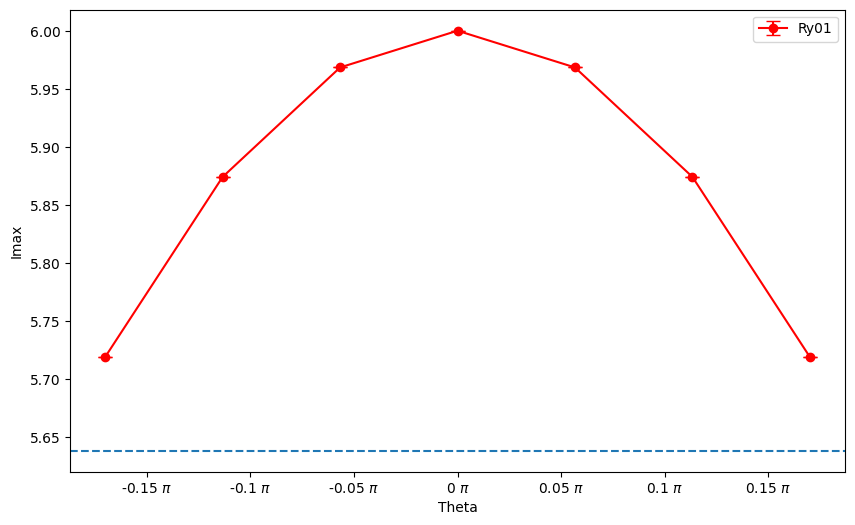

In [93]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 3, session=False)

1 of 7, Jobs num: 1
1 of 7, Jobs num: 2
1 of 7, Jobs num: 3
2 of 7, Jobs num: 1
2 of 7, Jobs num: 2
2 of 7, Jobs num: 3
3 of 7, Jobs num: 1
3 of 7, Jobs num: 2
3 of 7, Jobs num: 3
4 of 7, Jobs num: 1
4 of 7, Jobs num: 2
4 of 7, Jobs num: 3
5 of 7, Jobs num: 1
5 of 7, Jobs num: 2
5 of 7, Jobs num: 3
6 of 7, Jobs num: 1
6 of 7, Jobs num: 2
6 of 7, Jobs num: 3
7 of 7, Jobs num: 1
7 of 7, Jobs num: 2
7 of 7, Jobs num: 3
End of session
(5.230894463431825-0.08696634921057148j)
(5.079522015352147-0.01531465348681793j)
(5.043611275937015+0.05326819213132915j)
(5.016036466978589+0.016079927151408838j)
(4.959108930200767-0.029535239386160414j)
(5.110857421057966+0.04471424099958726j)
(4.956854419100351-0.0572051740328091j)


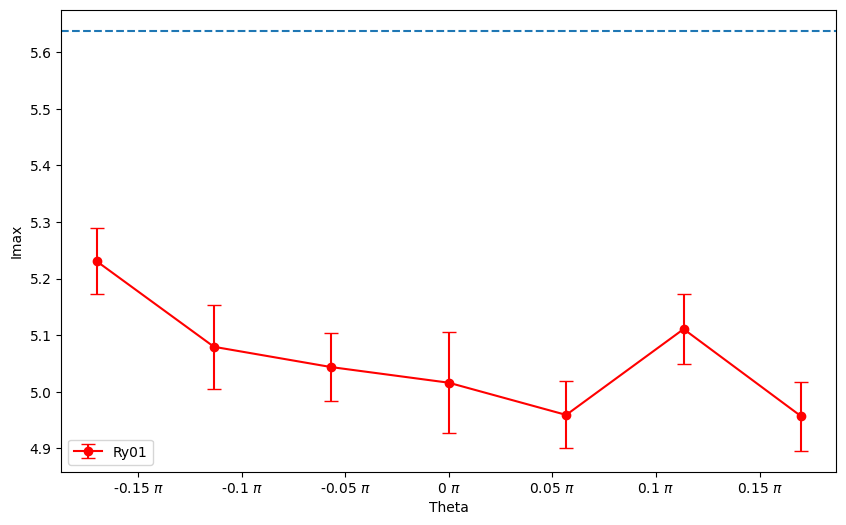

In [94]:
igvals, stds, thetas = chsh(-0.17*np.pi, 0.17*np.pi, 7, est, ghz_qc, 60, 3, session=True)

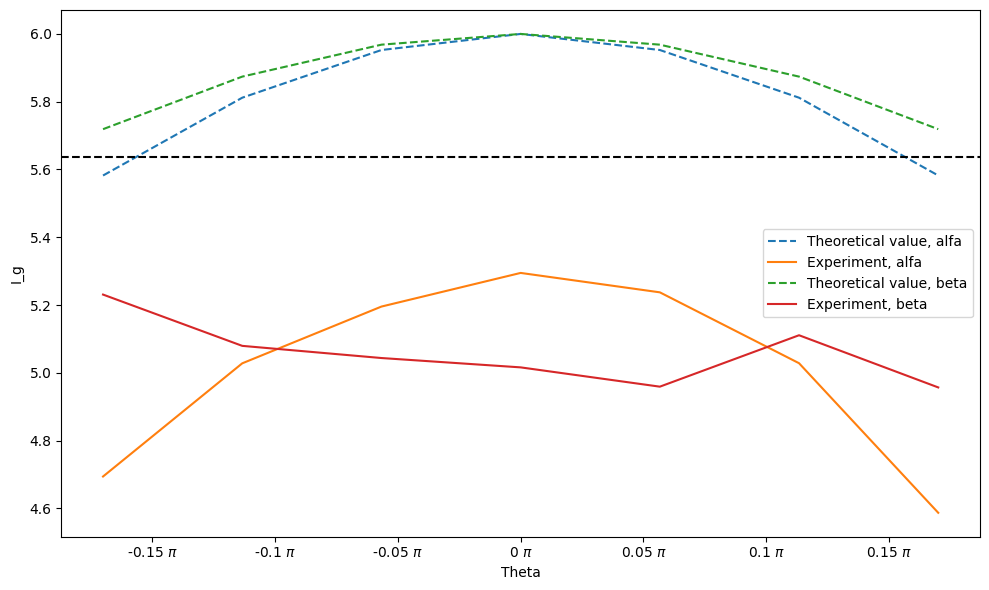

In [67]:
th1 = [5.582226081011847, 5.8118459684756925, 5.952586823907743, 6.000000000000012, 5.952586823907742, 5.811845968475694, 5.582226081011845]
ex1 = [4.693998932345366, 5.027974321362893, 5.195472179994078, 5.294753531419612, 5.237479262917729, 5.028315030824832, 4.586935472663389]
th2 = [5.718971700835148, 5.874064421368878, 5.968359869612331, 6.000000000000016, 5.968359869612342, 5.874064421368877, 5.71897170083515]
ex2 = [5.230894463431825, 5.079522015352147, 5.043611275937015, 5.016036466978589, 4.959108930200767, 5.110857421057966, 4.956854419100351]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-0.17*np.pi, 0.17*np.pi, 7)
plt.plot(x/np.pi, th1, linestyle='--',  label="Theoretical value, alfa")
plt.plot(x/np.pi, ex1, label="Experiment, alfa")
plt.plot(x/np.pi, th2, linestyle='--',  label="Theoretical value, beta")
plt.plot(x/np.pi, ex2, label="Experiment, beta")
ax.axhline(y=5.6381, linestyle="--", color="black")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("Theta")
plt.ylabel("I_g")
plt.legend()
plt.tight_layout()
plt.show()

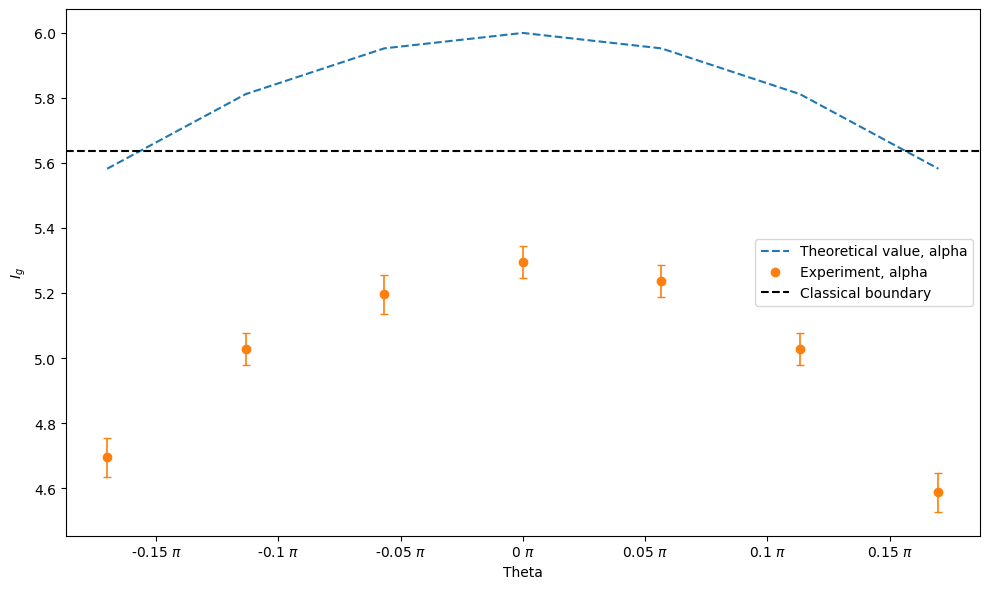

In [ ]:
th1 = [5.582226081011847, 5.8118459684756925, 5.952586823907743, 6.000000000000012, 5.952586823907742, 5.811845968475694, 5.582226081011845]
ex1 = [4.693998932345366, 5.027974321362893, 5.195472179994078, 5.294753531419612, 5.237479262917729, 5.028315030824832, 4.586935472663389]
th2 = [5.718971700835148, 5.874064421368878, 5.968359869612331, 6.000000000000016, 5.968359869612342, 5.874064421368877, 5.71897170083515]
ex2 = [5.230894463431825, 5.079522015352147, 5.043611275937015, 5.016036466978589, 4.959108930200767, 5.110857421057966, 4.956854419100351]

ex1_err = [0.06, 0.05, 0.06, 0.05, 0.05, 0.05, 0.06]  # alpha sweep
ex2_err = [0.05, 0.06, 0.05, 0.06, 0.05, 0.06, 0.05]  # beta sweep

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-0.17*np.pi, 0.17*np.pi, 7)

ax.plot(x/np.pi, th1, linestyle='--', label="Theoretical value, alpha")
# ax.plot(x/np.pi, th2, linestyle='--', label="Theoretical value, beta")


line1, = ax.plot(x/np.pi, ex1, marker='o', linestyle='none', label="Experiment, alpha")
ax.errorbar(x/np.pi, ex1, yerr=ex1_err, fmt='none',
            ecolor=line1.get_color(), elinewidth=1.2, capsize=3)

# line2, = ax.plot(x/np.pi, ex2, marker='o', linestyle='none', label="Experiment, beta")
# ax.errorbar(x/np.pi, ex2, yerr=ex2_err, fmt='none',
#             ecolor=line2.get_color(), elinewidth=1.2, capsize=3)


ax.axhline(y=5.6381, linestyle="--", color="black", label="Classical boundary")

ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.set_xlabel("Theta")
ax.set_ylabel("$I_g$")
ax.legend()
fig.tight_layout()
plt.show()

In [77]:
igval_list = [0.6, 0.1, -0.4, 1.0, 4.0, 5.6, 3.9, -0.1, -0.4, 0.2, 0.6]
exx = np.linspace(2*np.pi, 6*np.pi, 11)
stds_list  = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
thval = [0.6666666666666722, 0.6340514015363944, 0.5394115387682424, 0.39213756390682425, 0.20713773618850634, 0.0037763194038383796, -0.19551230430785094, -0.36684102821714765, -0.4866106658961252, -0.5332570654285781, -0.4888870725024874, -0.34069263177345865, -0.08204652810831181, 0.2867961407687038, 0.7584410440461291, 1.3185635478415911, 1.9465743404386022, 2.616702669623595, 3.2994306641840407, 3.9631890473733082, 4.57620718491556, 5.108399984171005, 5.533171361808373, 5.829019014219534, 5.980837737039635, 5.978867408263474, 5.829019014219542, 5.5331713618083675, 5.108399984170994, 4.576207184915559, 3.963189047373308, 3.2994306641840323, 2.61670266962361, 1.946574340438611, 1.3185635478415954, 0.7584410440461392, 0.2867961407687109, -0.08204652810830287, -0.3406926317734561, -0.48888707250248775, -0.5332570654285778, -0.48661066589612323, -0.3668410282171469, -0.19551230430784805, 0.003776319403834716, 0.2071377361885003, 0.39213756390682475, 0.5394115387682344, 0.6340514015363973, 0.6666666666666722]
thx = np.linspace(2*np.pi, 6*np.pi, 50)

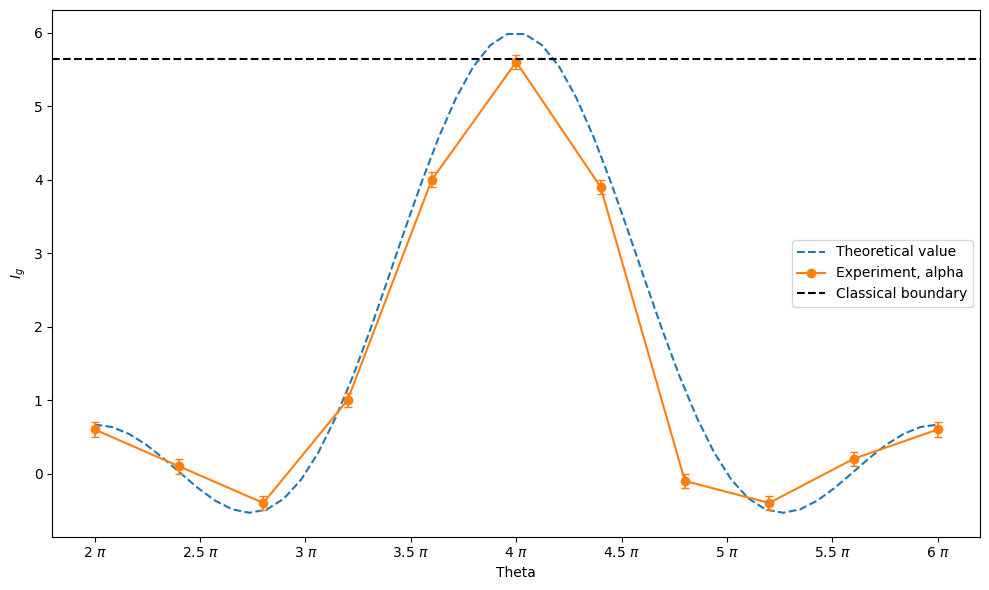

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Teoria
ax.plot(thx/np.pi, thval, linestyle='--', label="Theoretical value")

line1, = ax.plot(exx/np.pi, igval_list, marker='o', label="Experiment, alpha")
ax.errorbar(exx/np.pi, igval_list, yerr=stds_list, fmt='none',
            ecolor=line1.get_color(), elinewidth=1.2, capsize=3)

# Linia granicy klasycznej
ax.axhline(y=5.6381, linestyle="--", color="black", label="Classical boundary")

ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.set_xlabel("Theta")
ax.set_ylabel("$I_g$")
ax.legend()
fig.tight_layout()
plt.show()